In [1]:
import pandas as pd
import numpy as np 
import torch
import sklearn 
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import log_loss, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegressionCV
import matplotlib.pyplot as plt 
from collections import Counter
from matplotlib.patches import Rectangle

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


SEED = 42

# Part A

Input is raw image files of frontal chest X-ray (DICOM) per examination, output will be a label 0/1, a lung opacity tha could be pneumonia. 
Clinical question is that whether the patient has a chance of having pneunomia given the image and lung opacity, and do we need to further investigate. 

In [2]:
labels = pd.read_csv("assignment1_labels.csv")
mapping = pd.read_csv("rsna_to_nih_mapping.csv", dtype=str)

display(labels.head())
display(mapping.head())

from pathlib import Path
import pydicom
import matplotlib.pyplot as plt

row = labels.iloc[0]
image_path = (
    Path("data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248")
    / row["StudyInstanceUID"]
    / row["SeriesInstanceUID"]
    / f"{row['SOPInstanceUID']}.dcm"
)

ds = pydicom.dcmread(image_path)
pixels = ds.pixel_array

cmap = "gray_r" if ds.PhotometricInterpretation == "MONOCHROME1" else "gray"

plt.figure(figsize=(5, 5))
plt.imshow(pixels, cmap=cmap)
plt.title(f"Annotation Target: {row['Target']}")
plt.axis("off")
plt.show()

,patientId,x,y,width,height,Target,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID
0,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.5872.151787431...,1.2.276.0.7230010.3.1.3.8323329.5872.151787431...,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...
1,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.15466.15178743...,1.2.276.0.7230010.3.1.3.8323329.15466.15178743...,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...
2,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,564.0,356.0,274.0,496.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...
3,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,195.0,320.0,281.0,515.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...
4,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.22658.15178744...,1.2.276.0.7230010.3.1.3.8323329.22658.15178744...,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


In [3]:
display(labels['Target'].describe())
display((labels['Target'] == 0).mean())
display(((labels.drop_duplicates(subset = 'patientId', keep = 'first')['Target'] == 1).sum()))
display(((labels.drop_duplicates(subset = 'patientId', keep = 'first')['Target'] == 0).sum()))
mapping.drop_duplicates(subset = 'nih_patient_id', keep = 'first').count()


# 8964 and 20025. 
# NEW note: 25684 patients in total. distinct. 
#imbalanced dataset. 
# baseline should be better than majority guessing. 70% 
# corrected by codex. should be 78% multiple bounding boxes per positive. 
# didn't thought about that lol 
# we are doing medical imaging. we care about recall more than precesion.

count    28989.000000
mean         0.309221
std          0.462180
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Target, dtype: float64

np.float64(0.6907792610990375)

np.int64(5659)

np.int64(20025)

patientId         11171
nih_patient_id    11171
nih_image_id      11171
dtype: int64

We have 20025 negtaive cases and 5659 positive cases
22.0% positive and  78% negative


11171 patients in total
there are patients with multiple examinations. 

In [4]:
merged = labels.merge(mapping[['patientId','nih_patient_id','nih_image_id']], on="patientId", how="left", validate="many_to_one",)


In [5]:
patient_ids = merged["nih_patient_id"].unique()

train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state= SEED,
)

train = merged[
    merged["nih_patient_id"].isin(train_ids)
].copy().reset_index(drop=True)

test = merged[
    merged["nih_patient_id"].isin(test_ids)
].copy().reset_index(drop=True)

# distribution matches.
display(merged['patientId'].nunique(), len(merged))  
display(merged['patientId'].value_counts().value_counts()) 
display(merged.groupby('patientId')['Target'].nunique().max())


cols_to_drop = ['x', 'y', 'width', 'height']

images = merged.drop(columns = cols_to_drop).drop_duplicates()

train_img = train.drop(columns=cols_to_drop).drop_duplicates()
len(train_img)

test_img = test.drop(columns=cols_to_drop).drop_duplicates()
len(test_img)




25684

28989

count
1    22506
2     3062
3      105
4       11
Name: count, dtype: int64

1

4996

Create train and test first so we only look at train

In [6]:
pos = train_img.query('Target == 1').drop_duplicates('nih_patient_id').sample(4, random_state=SEED)
neg = train_img.query('Target == 0').drop_duplicates('nih_patient_id').sample(4, random_state=SEED)
panel = pd.concat([pos, neg], ignore_index=True)
assert panel['nih_patient_id'].nunique() == 8

In [7]:
IMG_ROOT = Path("data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248")
SEED = 42
CROP = 0.25         

def dcm_path(row):
    return (IMG_ROOT / row["StudyInstanceUID"] / row["SeriesInstanceUID"]
            / f"{row['SOPInstanceUID']}.dcm")

def decode(row):
    ds = pydicom.dcmread(dcm_path(row))
    if int(getattr(ds, "PixelRepresentation", 0)) == 1:
        raise ValueError("signed pixel data, not handled here")
    a = ds.pixel_array.astype("float32")
    
    stored_max = float(2 ** int(getattr(ds, "BitsStored", 16)) - 1)
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        a = stored_max - a            
    return ds, a / stored_max 

pos = train_img.query("Target == 1").drop_duplicates("nih_patient_id").sample(4, random_state=SEED)
neg = train_img.query("Target == 0").drop_duplicates("nih_patient_id").sample(4, random_state=SEED)
panel = pd.concat([pos, neg], ignore_index=True)
assert panel["nih_patient_id"].nunique() == 8, "panel must use 8 distinct source patients"

rows_per_exam = train.groupby("patientId").size()
multi_ids = rows_per_exam[rows_per_exam > 1].index
cands = train[(train["Target"] == 1) & train["patientId"].isin(multi_ids)]
chosen = cands["patientId"].drop_duplicates().sample(1, random_state=SEED).iloc[0]
boxes = train[train["patientId"] == chosen]

decoded, failures = [], []
for _, row in panel.iterrows():
    try:
        ds, a = decode(row)
    except Exception as e:
        failures.append((row["SOPInstanceUID"], repr(e)))
        continue
    decoded.append({"Target": int(row["Target"]), "row": row, "ds": ds, "img": a})

ds_extra, img_extra = decode(boxes.iloc[0])

print("decoded:", len(decoded), "+ 1 multi-box | failures:", failures)
print("multi-box examination has", len(boxes), "box rows")
print("polarities:", Counter(e["ds"].PhotometricInterpretation for e in decoded))
print("BitsStored values:", sorted({getattr(e["ds"], "BitsStored", None) for e in decoded}))
print("image sizes:", sorted({(e["ds"].Rows, e["ds"].Columns) for e in decoded}))

decoded: 8 + 1 multi-box | failures: []
multi-box examination has 2 box rows
polarities: Counter({'MONOCHROME2': 8})
BitsStored values: [8]
image sizes: [(1024, 1024)]


In [8]:
def meta_row(entry):
    ds, row = entry["ds"], entry["row"]
    return {
        "Target": entry["Target"],
        "source_patient": row["nih_patient_id"],
        "PhotometricInterpretation": ds.PhotometricInterpretation,
        "BitsStored": getattr(ds, "BitsStored", None),
        "Rows": ds.Rows, "Columns": ds.Columns,
        "PixelSpacing": getattr(ds, "PixelSpacing", None),
        "RescaleSlope": getattr(ds, "RescaleSlope", None),
        "RescaleIntercept": getattr(ds, "RescaleIntercept", None),
        "WindowCenter": str(getattr(ds, "WindowCenter", None)),
        "WindowWidth": str(getattr(ds, "WindowWidth", None)),
    }

notes = pd.DataFrame([meta_row(e) for e in decoded])
for col in ["view", "mark_visible", "mark_content", "mark_shape",
            "mark_position", "mark_overlaps_lung", "burned_in"]:
    notes[col] = ""

In [9]:
n = len(decoded)
fig, axes = plt.subplots(n, 2, figsize=(9, 2.7 * n))

for i, e in enumerate(decoded):
    a = e["img"]
    h = max(1, int(a.shape[0] * CROP))
    w = max(1, int(a.shape[1] * CROP))
    ax0, ax1 = axes[i]

    ax0.imshow(a, cmap="gray", vmin = 0, vmax = 1)
    ax0.set_title(f"{i}: Target={e['Target']} | {e['ds'].PhotometricInterpretation} | "
                f"{getattr(e['ds'], 'BitsStored', '?')}-bit | {a.shape[0]}x{a.shape[1]}",
                fontsize=9)
    ax0.set_xticks([]); ax0.set_yticks([])

    ax1.imshow(a[:h, -w:], cmap="gray", vmin = 0, vmax = 1)
    ax1.set_title("top-right crop", fontsize=9)
    ax1.set_xticks([]); ax1.set_yticks([])

plt.tight_layout()
plt.show()

[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


Picture index 1 shows that it's a bit harder. Since it is quite distorted and the image isn't super clear as well. This could be a difficult case. 

The contrast isn't really high, and it's a bit rotated, and then there are tubes or wirey things overlying the lungs. 

In [10]:
# Inspect the bounding boxes
a = img_extra
h = max(1, int(a.shape[0] * CROP))
w = max(1, int(a.shape[1] * CROP))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(a, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"plain — {len(boxes)} box rows in the CSV", fontsize=10)

axes[1].imshow(a, cmap="gray", vmin=0, vmax=1)
for _, b in boxes.iterrows():
    if pd.notna(b["x"]):
        axes[1].add_patch(Rectangle((b["x"], b["y"]), b["width"], b["height"],
                                    fill=False, edgecolor="red", lw=1.2))
axes[1].set_title("with the CSV boxes drawn on top", fontsize=10)

axes[2].imshow(a[:h, -w:], cmap="gray", vmin=0, vmax=1)
axes[2].set_title("top-right crop", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

display(boxes[["x", "y", "width", "height"]])

[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


,x,y,width,height
1373,517.0,526.0,300.0,317.0
1395,118.0,568.0,305.0,244.0


In [11]:
from concurrent.futures import ThreadPoolExecutor
HEADER_CACHE = Path("../outputs/dicom_headers.csv")
# outputs/ is git-ignored
TAGS = ["ViewPosition", "Rows", "Columns", "PhotometricInterpretation", "BitsStored"]
def read_header(r):
    ds = pydicom.dcmread (dcm_path(r), stop_before_pixels=True, specific_tags=TAGS)
    return {"patientId": r["patientId"], **{t: ds.get(t) for t in TAGS}}
if HEADER_CACHE.exists():
    headers = pd.read_csv(HEADER_CACHE)
else:
    with ThreadPoolExecutor(max_workers=8) as pool:
        headers = pd.DataFrame(list(pool.map(read_header, images.to_dict("records"))))
    headers.to_csv(HEADER_CACHE, index = False )
assert len (headers) == len(images) == headers ["patientId"].nunique () == 25684
headers ["size"] = headers ["Rows"].astype(str) + "x" + headers ["Columns"].astype(str)
for col in ["size", "PhotometricInterpretation", "BitsStored", "ViewPosition"]:
    display (headers[col].value_counts (dropna=False))


size
1024x1024    25684
Name: count, dtype: int64

PhotometricInterpretation
MONOCHROME2    25684
Name: count, dtype: int64

BitsStored
8    25684
Name: count, dtype: int64

ViewPosition
PA    13979
AP    11705
Name: count, dtype: int64

# Part B

We did raw some sampling in the first part because we want to inspect 

We decided to use the builtin stratifiedgroupfold for validation and train split since it would be best. or else we have to write it ourselves everytime. and for same split we can simply use a fixed seed.

Test should be only used at final evaluation. 

In [12]:
merged.groupby('nih_patient_id')['patientId'].nunique().value_counts()
# we need stratified group fold here because of this. imbalanced class and multiple groups

patientId
1     6973
2     1738
3      914
4      416
5      283
6      172
7      145
8       92
9       73
10      60
12      38
11      38
13      33
14      30
15      30
17      16
18      16
19      14
16      14
20      12
24       9
22       8
26       5
21       5
23       4
25       4
40       3
30       3
35       3
28       2
43       2
29       2
46       2
42       2
27       2
33       1
34       1
37       1
63       1
59       1
52       1
38       1
31       1
Name: count, dtype: int64

In [13]:
train_idx, val_idx = next(sgkf.split(train_img, y = train_img["Target"], groups = train_img["nih_patient_id"]))



train: val: test = 16:4:5 

tain + val : test = 4: 1

In [14]:
val_img = train_img.iloc[val_idx]
tr_img = train_img.iloc[train_idx]

tr_p = set(tr_img["nih_patient_id"])
val_p = set(val_img["nih_patient_id"])
test_p = set(test_img["nih_patient_id"])

assert tr_p.isdisjoint(val_p)
assert test_p.isdisjoint(val_p)
assert tr_p.isdisjoint(test_p)

all_exams = pd.concat([tr_img["patientId"], val_img["patientId"], test_img["patientId"]])
assert all_exams.is_unique and len(all_exams) == len(images) == 25684
assert len(tr_p | val_p | test_p) == images["nih_patient_id"].nunique() == 11171
print("B3 passed: 3 disjoint patient sets; every examination in exactly one split")

B3 passed: 3 disjoint patient sets; every examination in exactly one split


In [15]:
rows = []

for name, d in [("train", tr_img), ("validation", val_img), ("test", test_img), ("all", images)]:
    rows.append({"split" : name,
                 "source_patients": d["nih_patient_id"].nunique(),
                 "examinations": len(d),
                 "positive exams": int(d["Target"].sum()),
                 "positive % ": round(100 * d["Target"].mean(), 2)

    })

split_table = pd.DataFrame(rows).set_index("split")
display(split_table)

parts = ["train", "validation", "test"]
cols = ["source_patients", "examinations", "positive exams"]
assert(split_table.loc[parts, cols].sum() == split_table.loc["all", cols]).all()

,source_patients,examinations,positive exams,positive %
split,,,,
train,7125,16564,3718,22.45
validation,1811,4124,891,21.61
test,2235,4996,1050,21.02
all,11171,25684,5659,22.03


In [16]:
from sklearn.metrics import roc_auc_score
tr_view = tr_img.merge(headers[["patientId", "ViewPosition"]], on="patientId", how="left", validate="one_to_one")
assert len(tr_view) == len(tr_img) and tr_view["ViewPosition"].notna().all()
view_table = tr_view.groupby("ViewPosition") ["Target"].agg(
examinations="size", positives="sum", positive_rate="mean")
view_table["positive %"] = (100 * view_table.pop("positive_rate")).round (2)
display(view_table)
auc_view = roc_auc_score(tr_view["Target"], tr_view["ViewPosition"] == "AP")
print(f"ROC-AUC of view alone (AP = predict positive): {auc_view:.3f}")

,examinations,positives,positive %
ViewPosition,,,
AP,7608,2866,37.67
PA,8956,852,9.51


ROC-AUC of view alone (AP = predict positive): 0.701


AP films are 4 times more positive than PA films. this is reasonable as AP are usually more severe patients. and 2866 of 3718 positives are AP, up to almost 80%. 


Patient level grouping doesn't work now since we're groupng by patient, not the view. If the model learns that AP means positive then it's like cheating a little bit

In this case, we need to test within-view AUC like AUC with AP only and PA only, and alo mask the borders. where the markers are.

# Part C

### C1: DICOM to model-ready tensor

I first checked the 25,684 DICOM images and found that they were all 8-bit MONOCHROME2 images with a resolution of 1024×1024. Since the pixel values were already normal grayscale values from 0 to 255, I did not need to do any extra windowing, inversion, or rescaling. I decoded each image, scaled the values to [0,1], and resized it to 224×224 using bilinear interpolation with antialiasing. I also saved the resized images as uint8 arrays so I would not have to decode all the DICOM files again every time I trained the model. Before feeding the images into the model, I converted them to (1,224,224) tensors and normalized them using the mean (0.4903) and standard deviation (0.2470) calculated only from the training set. This way, I avoided using any information from the validation or test sets. I applied the training augmentations described in C2 before this normalization step.

In [17]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

IMG_SIZE = 224
IMG_CACHE = Path(f"../outputs/images_{IMG_SIZE}.npy")
ID_CACHE = Path(f"../outputs/images_{IMG_SIZE}_ids.csv")

def load_resized(row):
    _, a = decode(row)
    t = torch.from_numpy(a)[None, None]
    t = F.interpolate(t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear",
                      antialias=True, align_corners=False)
    return (t[0, 0] * 255).round().to(torch.uint8).numpy()

if IMG_CACHE.exists() and ID_CACHE.exists():
    X = np.load(IMG_CACHE)
    ids = pd.read_csv(ID_CACHE)["patientId"]
else:
    with ThreadPoolExecutor(max_workers=8) as pool:
        X = np.stack(list(pool.map(load_resized, images.to_dict("records"))))
    ids = images["patientId"].reset_index(drop=True)
    np.save(IMG_CACHE, X)
    ids.to_frame().to_csv(ID_CACHE, index=False)

assert X.shape == (len(images), IMG_SIZE, IMG_SIZE) and X.dtype == np.uint8
row_of = pd.Series(np.arange(len(ids)), index=ids.values)
print(X.shape, X.dtype)

(25684, 224, 224) uint8


In [18]:
tr_rows = row_of[tr_img["patientId"]].values
s = s2 = 0.0
for start in range(0, len(tr_rows), 1000):
    b = X[tr_rows[start:start + 1000]].astype(np.float64) / 255
    s += b.sum()
    s2 += (b ** 2).sum()
n = len(tr_rows) * IMG_SIZE * IMG_SIZE
TRAIN_MEAN = s / n
TRAIN_STD = float(np.sqrt(s2 / n - TRAIN_MEAN ** 2))
print(f"training-split pixel mean = {TRAIN_MEAN:.4f}, std = {TRAIN_STD:.4f} (0-1 scale)")

training-split pixel mean = 0.4903, std = 0.2470 (0-1 scale)


In [19]:
class CXRDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.rows = row_of[frame["patientId"]].values
        self.y = frame["Target"].values.astype("float32")
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        x = torch.from_numpy(X[self.rows[i]]).float().div(255).unsqueeze(0)
        if self.transform is not None:
            x = self.transform(x)
        x = (x - TRAIN_MEAN) / TRAIN_STD
        return x, torch.tensor(self.y[i])

xb, yb = next(iter(DataLoader(CXRDataset(tr_img), batch_size=32)))
print(tuple(xb.shape), xb.dtype, f"mean {xb.mean():.3f}  std {xb.std():.3f}")
assert xb.shape == (32, 1, IMG_SIZE, IMG_SIZE)
assert (load_resized(images.iloc[0]) == X[0]).all(), "cache differs from a fresh decode"

(32, 1, 224, 224) torch.float32 mean 0.085  std 0.997


### C2: training-only augmentation

For training, I used a few small augmentations to make the model more robust to normal differences between chest X-rays. I randomly rotated images by up to ±7°, translated them by up to 5%, and scaled them between 0.95 and 1.05 to simulate differences in patient positioning. I also changed the brightness and contrast by up to ±10% to account for differences in exposure and image processing. I kept these changes small so that the anatomy remained realistic and important findings such as opacities were not removed from the image. Any empty areas created by rotation or translation were filled with black pixels. I applied these augmentations only to the training set; validation and test images were left unchanged.

In [20]:
train_aug = v2.Compose([
    v2.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05), fill=0.0),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
])
print(train_aug)

torch.manual_seed(SEED)
demo = tr_img.sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for j, (_, r) in enumerate(demo.iterrows()):
    x = torch.from_numpy(X[row_of[r["patientId"]]]).float().div(255).unsqueeze(0)
    axes[0, j].imshow(x[0], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"original | Target={r['Target']}", fontsize=9)
    axes[1, j].imshow(train_aug(x)[0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("augmented", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Compose(
      RandomAffine(degrees=[-7.0, 7.0], translate=(0.05, 0.05), scale=(0.95, 1.05), interpolation=InterpolationMode.NEAREST, fill=0.0)
      ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1))
)


[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


In [21]:
train_ds = CXRDataset(tr_img, transform=train_aug)
val_ds = CXRDataset(val_img)

a, _ = val_ds[0]; b, _ = val_ds[0]
assert torch.equal(a, b), "validation images must be identical every time"
a, _ = train_ds[0]; b, _ = train_ds[0]
assert not torch.equal(a, b), "training images should vary between calls"
print("validation path is clean; augmentation applies to training only")

validation path is clean; augmentation applies to training only


### C3: transformations not used


I chose not to use more aggressive transformations such as flipping, large rotations, shear, cropping, or erasing because they could create unrealistic chest X-rays or remove important findings while keeping the original label. I also did not apply border masking, as I wanted to keep the original images intact and later test whether the model was relying on border information or markers.

### C4: class imbalance
Since only 22.45% of the training images were positive, I used a weighted binary cross-entropy loss with `pos_weight = 3.455` to give positive cases more importance during training. I preferred this over oversampling because it avoids repeatedly showing the same positive images. In the validation set, weighting increased sensitivity from 0.387 to 0.745 and F1 from 0.464 to 0.553, although specificity decreased from 0.922 to 0.738. ROC-AUC and PR-AUC changed very little, showing that weighting mainly shifts the model towards detecting more positive cases rather than improving its overall ranking ability. I therefore kept the weighted loss for the remaining models.

In [22]:
n_pos = int(tr_img["Target"].sum())
n_neg = len(tr_img) - n_pos
POS_WEIGHT = torch.tensor([n_neg / n_pos])
print(f"train: {n_pos} positive, {n_neg} negative -> pos_weight = {POS_WEIGHT.item():.3f}")

loss_plain = nn.BCEWithLogitsLoss()
loss_weighted = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)

logit = torch.logit(torch.tensor([0.2]))
for y in (1.0, 0.0):
    t = torch.tensor([y])
    print(f"true label {int(y)}: plain loss {loss_plain(logit, t):.3f}, weighted {loss_weighted(logit, t):.3f}")

train: 3718 positive, 12846 negative -> pos_weight = 3.455
true label 1: plain loss 1.609, weighted 5.561
true label 0: plain loss 0.223, weighted 0.223


# Part D

### Training and evaluation tools

I created a set of reusable functions for training and evaluating the models in Parts D, E, and F. run_epoch runs through the dataset once and updates the model weights during training, while fit handles the full training process with Adam, tracks training and validation loss, and uses early stopping to reduce overfitting. After training, I use predict to get the predicted probabilities and metrics to calculate the confusion matrix, accuracy, sensitivity, specificity, precision, F1, ROC-AUC, and PR-AUC.

In [23]:
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
import time
import itertools

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE)
            loss = loss_fn(model(x).squeeze(1), y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(y)
            n += len(y)
    return total / n

def fit(model, train_loader, val_loader, loss_fn, lr, weight_decay=0.0, max_epochs=30, patience=5):
    model.to(DEVICE)
    loss_fn.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_loss, best_state, bad, history = float("inf"), None, 0, []
    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss = run_epoch(model, val_loader, loss_fn)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_loss:
            best_loss, bad = val_loss, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        ps.append(torch.sigmoid(model(x.to(DEVICE)).squeeze(1)).cpu())
        ys.append(y)
    return torch.cat(ys).numpy().astype(int), torch.cat(ps).numpy()

def metrics(y, p, threshold=0.5):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "accuracy": (tp + tn) / len(y),
            "sensitivity": tp / (tp + fn) if tp + fn else np.nan,
            "specificity": tn / (tn + fp) if tn + fp else np.nan,
            "precision": tp / (tp + fp) if tp + fp else np.nan,
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan,
            "ROC-AUC": roc_auc_score(y, p),
            "PR-AUC": average_precision_score(y, p)}

device: cuda


### D1: trivial baseline

Trivial Baseline is always predicting the majority class. so 0. 

In [24]:
trivial = pd.DataFrame({
    "validation": metrics(val_img["Target"].values, np.zeros(len(val_img))),
    "test": metrics(test_img["Target"].values, np.zeros(len(test_img))),
}).T
display(trivial.round(4))

,TP,FP,TN,FN,accuracy,sensitivity,specificity,precision,F1,ROC-AUC,PR-AUC
validation,0.0,0.0,3233.0,891.0,0.7839,0.0,1.0,NaN,0.0,0.5,0.2161
test,0.0,0.0,3946.0,1050.0,0.7898,0.0,1.0,NaN,0.0,0.5,0.2102


### D2: simple PyTorch baseline (pixel MLP)

For my baseline, I used a simple multilayer perceptron (MLP). I flattened each normalized 224×224 X-ray into 50,176 pixel values and used them directly as the model input. I trained the model using the weighted BCE loss from C4, the Adam optimizer, and early stopping to reduce overfitting. I randomly tested 12 combinations of hidden layers, layer size, learning rate, weight decay, and dropout, and selected the model with the highest validation ROC-AUC without using the test set. I did not use augmentation for this baseline to keep the search simple and fast. The main limitation is that flattening the image removes its spatial structure, and the large number of model parameters also makes the MLP more likely to overfit compared with a CNN.

In [25]:
BATCH = 256
val_loader = DataLoader(CXRDataset(val_img), batch_size=512)

def make_train_loader(seed):
    return DataLoader(CXRDataset(tr_img), batch_size=BATCH, shuffle=True,
                      generator=torch.Generator().manual_seed(seed))

def make_mlp(n_hidden, width, dropout):
    layers, d = [nn.Flatten()], IMG_SIZE * IMG_SIZE
    for _ in range(n_hidden):
        layers += [nn.Linear(d, width), nn.ReLU(), nn.Dropout(dropout)]
        d = width
    layers.append(nn.Linear(d, 1))
    return nn.Sequential(*layers)

def train_config(cfg, loss_fn, seed=SEED):
    torch.manual_seed(seed)
    model = make_mlp(cfg["n_hidden"], cfg["width"], cfg["dropout"])
    model, history = fit(model, make_train_loader(seed), val_loader, loss_fn,
                         lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    y, p = predict(model, val_loader)
    return model, history, y, p

GRID = {"n_hidden": [1, 2], "width": [64, 128, 256], "lr": [1e-4, 3e-4, 1e-3],
        "weight_decay": [0.0, 1e-4], "dropout": [0.0, 0.3]}
N_TRIALS = 12
all_configs = [dict(zip(GRID, values)) for values in itertools.product(*GRID.values())]
rng = np.random.default_rng(SEED)
configs = [all_configs[i] for i in rng.choice(len(all_configs), size=N_TRIALS, replace=False)]
print(f"{len(all_configs)} possible configurations, {N_TRIALS} sampled")

72 possible configurations, 12 sampled


In [26]:
results, best = [], None
for trial, cfg in enumerate(configs, start=1):
    start = time.time()
    model, history, y, p = train_config(cfg, loss_weighted)
    m = metrics(y, p)
    best_epoch = int(history.loc[history["val_loss"].idxmin(), "epoch"])
    results.append({"trial": trial, **cfg, "epochs_run": len(history), "best_epoch": best_epoch,
                    "val_loss": history["val_loss"].min(), "val_ROC-AUC": m["ROC-AUC"],
                    "val_PR-AUC": m["PR-AUC"], "seconds": round(time.time() - start, 1)})
    print(f"trial {trial:2d}/{N_TRIALS}: {cfg} -> val ROC-AUC {m['ROC-AUC']:.4f}")
    if best is None or m["ROC-AUC"] > best["auc"]:
        best = {"auc": m["ROC-AUC"], "cfg": cfg, "model": model, "history": history, "y": y, "p": p}

search_table = pd.DataFrame(results).sort_values("val_ROC-AUC", ascending=False)
display(search_table.round(4))
BEST_CFG = best["cfg"]
print("selected configuration:", BEST_CFG)

trial  1/12: {'n_hidden': 1, 'width': 256, 'lr': 0.0003, 'weight_decay': 0.0, 'dropout': 0.0} -> val ROC-AUC 0.8006
trial  2/12: {'n_hidden': 2, 'width': 256, 'lr': 0.0003, 'weight_decay': 0.0001, 'dropout': 0.0} -> val ROC-AUC 0.7985
trial  3/12: {'n_hidden': 2, 'width': 64, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3} -> val ROC-AUC 0.7914
trial  4/12: {'n_hidden': 2, 'width': 64, 'lr': 0.0001, 'weight_decay': 0.0, 'dropout': 0.3} -> val ROC-AUC 0.7995
trial  5/12: {'n_hidden': 2, 'width': 64, 'lr': 0.0003, 'weight_decay': 0.0, 'dropout': 0.3} -> val ROC-AUC 0.7992
trial  6/12: {'n_hidden': 2, 'width': 128, 'lr': 0.001, 'weight_decay': 0.0, 'dropout': 0.0} -> val ROC-AUC 0.8011
trial  7/12: {'n_hidden': 1, 'width': 64, 'lr': 0.0003, 'weight_decay': 0.0, 'dropout': 0.3} -> val ROC-AUC 0.8003
trial  8/12: {'n_hidden': 2, 'width': 256, 'lr': 0.0003, 'weight_decay': 0.0, 'dropout': 0.0} -> val ROC-AUC 0.8067
trial  9/12: {'n_hidden': 1, 'width': 64, 'lr': 0.0003, 'weight_decay': 

,trial,n_hidden,width,lr,weight_decay,dropout,epochs_run,best_epoch,val_loss,val_ROC-AUC,val_PR-AUC,seconds
11,12,1,128,0.0001,0.0000,0.3,13,8,0.8199,0.8074,0.5070,43.7
7,8,2,256,0.0003,0.0000,0.0,11,6,0.8382,0.8067,0.5165,52.2
9,10,2,256,0.0003,0.0001,0.3,19,14,0.8351,0.8059,0.5223,86.1
10,11,2,256,0.0010,0.0001,0.0,11,6,0.8686,0.8038,0.5046,45.5
8,9,1,64,0.0003,0.0001,0.0,12,7,0.8362,0.8023,0.5067,48.4
5,6,2,128,0.0010,0.0000,0.0,12,7,0.8644,0.8011,0.5014,52.5
0,1,1,256,0.0003,0.0000,0.0,9,4,0.8656,0.8006,0.4858,35.9
6,7,1,64,0.0003,0.0000,0.3,20,15,0.8470,0.8003,0.4946,80.9
3,4,2,64,0.0001,0.0000,0.3,15,10,0.8364,0.7995,0.5012,58.6
4,5,2,64,0.0003,0.0000,0.3,12,7,0.8380,0.7992,0.4954,42.6


selected configuration: {'n_hidden': 1, 'width': 128, 'lr': 0.0001, 'weight_decay': 0.0, 'dropout': 0.3}


### C4 ablation

The selected configuration is retrained with the unweighted loss, using the same seed, split and early-stopping rule, so the loss weighting is the only difference. Both versions are compared on the validation split. The loss curves of the selected (weighted) model are shown first.

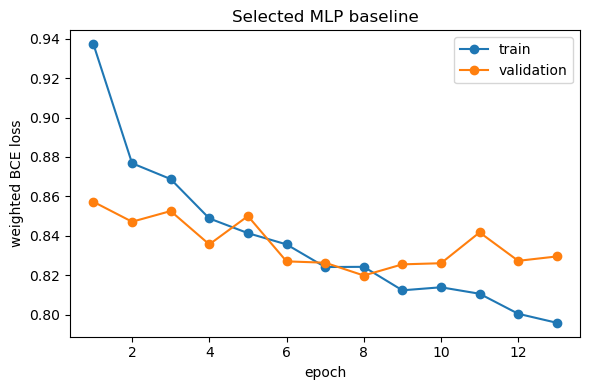

,TP,FP,TN,FN,accuracy,sensitivity,specificity,precision,F1,ROC-AUC,PR-AUC
with pos_weight,664.0,846.0,2387.0,227.0,0.7398,0.7452,0.7383,0.4397,0.5531,0.8074,0.5070
without pos_weight,345.0,252.0,2981.0,546.0,0.8065,0.3872,0.9221,0.5779,0.4637,0.8114,0.5336


In [27]:
h = best["history"]
plt.figure(figsize=(6, 4))
plt.plot(h["epoch"], h["train_loss"], marker="o", label="train")
plt.plot(h["epoch"], h["val_loss"], marker="o", label="validation")
plt.xlabel("epoch"); plt.ylabel("weighted BCE loss"); plt.title("Selected MLP baseline")
plt.legend(); plt.tight_layout(); plt.show()

_, _, y_plain, p_plain = train_config(BEST_CFG, loss_plain)
ablation = pd.DataFrame({
    "with pos_weight": metrics(best["y"], best["p"]),
    "without pos_weight": metrics(y_plain, p_plain),
}).T
display(ablation.round(4))

### D3: final evaluation on the test split

The selected baseline is evaluated once on the test split at the default threshold of 0.5. The validation and test predictions and the model weights are saved to `outputs/`, so Part F can reuse them without evaluating on the test split again. Operating thresholds are chosen on the validation split in Part F.

In [28]:
baseline_model = best["model"]
test_ds = CXRDataset(test_img)
test_loader = DataLoader(test_ds, batch_size=512)
y_test, p_test = predict(baseline_model, test_loader)
assert (y_test == test_img["Target"].values).all()
assert (best["y"] == val_img["Target"].values).all()

baseline_test = pd.DataFrame({"MLP baseline (test, threshold 0.5)": metrics(y_test, p_test)}).T
display(baseline_test.round(4))

val_pred_baseline = pd.DataFrame({"patientId": val_img["patientId"].values, "Target": best["y"], "p": best["p"]})
test_pred_baseline = pd.DataFrame({"patientId": test_img["patientId"].values, "Target": y_test, "p": p_test})
val_pred_baseline.to_csv("../outputs/val_pred_baseline.csv", index=False)
test_pred_baseline.to_csv("../outputs/test_pred_baseline.csv", index=False)
torch.save(baseline_model.state_dict(), "../outputs/baseline_mlp.pt")
print("saved validation/test predictions and model weights to ../outputs/")

,TP,FP,TN,FN,accuracy,sensitivity,specificity,precision,F1,ROC-AUC,PR-AUC
"MLP baseline (test, threshold 0.5)",797.0,998.0,2948.0,253.0,0.7496,0.759,0.7471,0.444,0.5603,0.8153,0.4983


saved validation/test predictions and model weights to ../outputs/


### D4: interpretation

The trivial baseline achieved relatively high accuracy (79.0% on the test set) simply by predicting every image as negative, but it completely failed to identify positive cases. My pixel MLP performed much better, reaching a test ROC-AUC of 0.815 and PR-AUC of 0.498, with sensitivity of 0.759 and specificity of 0.747. The 12 hyperparameter configurations gave very similar validation ROC-AUC values (0.791–0.807), suggesting that performance was not very sensitive to the settings I tested. The selected model started to overfit after around eight epochs, which was controlled using early stopping. Class weighting substantially increased sensitivity but reduced specificity and precision, while ROC-AUC changed very little, showing that weighting mainly changed the model’s operating point rather than its overall ranking ability. Although the MLP performed surprisingly well for a model using flattened pixels, some of this performance may come from acquisition-related differences, such as AP versus PA views, rather than opacity itself, which I investigate further in section G.

# Part E

### Seed control

I fixed the random seeds for Python, NumPy, and PyTorch to make the experiments as reproducible as possible. I trained each model using three seeds (42, 43, and 44), while keeping the same patient-level training, validation, and test splits for every run. This lets me check whether the results are consistent rather than depending on one lucky training run.

In [29]:
import random
from torchvision.models import resnet18, ResNet18_Weights

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEEDS = [42, 43, 44]
print("seeds:", SEEDS, "| split seed:", SEED, "| cudnn.deterministic:", True)

seeds: [42, 43, 44] | split seed: 42 | cudnn.deterministic: True


### E1: adapting an ImageNet-pretrained ResNet-18


I used an ImageNet-pretrained ResNet-18 as my CNN model. Since the pretrained model expects three-channel RGB images but my X-rays are single-channel grayscale, I changed the first convolutional layer to accept one channel and combined the pretrained RGB weights so that I could keep the pretrained information. I also replaced the original 1,000-class ImageNet output layer with a single output for binary classification. The model outputs one logit, which is converted to a probability using sigmoid, and I used the same weighted BCE loss (`pos_weight = 3.455`) as in the baseline.

In [30]:
class ResNetCXR(nn.Module):
    def __init__(self):
        super().__init__()
        net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        summed = net.conv1.weight.detach().sum(dim=1, keepdim=True)
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        net.conv1.weight.data.copy_(summed)
        net.fc = nn.Linear(net.fc.in_features, 1)
        self.net = net
        self.trainable = list(dict(net.named_children()))

    def set_stage(self, stage):
        self.trainable = ["fc"] if stage == 1 else ["layer4", "fc"]
        for name, module in self.net.named_children():
            for p in module.parameters():
                p.requires_grad = name in self.trainable

    def train(self, mode=True):
        super().train(mode)
        if mode:
            for name, module in self.net.named_children():
                if name not in self.trainable:
                    module.eval()
        return self

    def forward(self, x):
        return self.net(x)

original_conv1 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).conv1
x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE)
assert torch.allclose(ResNetCXR().net.conv1(x), original_conv1(x.repeat(1, 3, 1, 1)), atol=1e-4)
print("1-channel conv1 on a grey image == pretrained RGB conv1 on the image repeated 3 times")

demo_model = ResNetCXR()
for stage in (1, 2):
    demo_model.set_stage(stage)
    n_train = sum(p.numel() for p in demo_model.parameters() if p.requires_grad)
    n_all = sum(p.numel() for p in demo_model.parameters())
    print(f"stage {stage}: training {demo_model.trainable} -> {n_train:,} of {n_all:,} parameters")

1-channel conv1 on a grey image == pretrained RGB conv1 on the image repeated 3 times
stage 1: training ['fc'] -> 513 of 11,170,753 parameters
stage 2: training ['layer4', 'fc'] -> 8,394,241 of 11,170,753 parameters


### E2: two-stage training

I trained the ResNet-18 in two stages. First, I froze all the pretrained layers and trained only the new classification head, allowing it to learn the new task without changing the pretrained features. I then unfroze the final convolutional block (`layer4`) and the classification head and fine-tuned them using a lower learning rate, while keeping the earlier layers frozen. This approach lets the model gradually adapt its ImageNet features to chest X-rays without changing the pretrained weights too aggressively. For a fair comparison with the baseline, I kept the same patient-level splits, weighted loss, early stopping, and evaluation metrics, while the CNN additionally used the training augmentations from C2.

In [31]:
CNN_BATCH = 64
WORKERS = 6
STAGE1 = {"lr": 1e-3, "max_epochs": 10, "patience": 3}
STAGE2 = {"lr": 1e-4, "max_epochs": 15, "patience": 4}

def make_cnn_train_loader(seed):
    return DataLoader(train_ds, batch_size=CNN_BATCH, shuffle=True, num_workers=WORKERS,
                      pin_memory=True, generator=torch.Generator().manual_seed(seed))

def run_cnn(seed):
    set_seed(seed)
    model = ResNetCXR()
    train_loader = make_cnn_train_loader(seed)
    model.set_stage(1)
    model, h1 = fit(model, train_loader, val_loader, loss_weighted, **STAGE1)
    _, p1 = predict(model, val_loader)
    model.set_stage(2)
    model, h2 = fit(model, train_loader, val_loader, loss_weighted, **STAGE2)
    y, p2 = predict(model, val_loader)
    return {"model": model, "h1": h1, "h2": h2, "y": y, "p1": p1, "p2": p2}

start = time.time()
cnn = {42: run_cnn(42)}
print(f"seed 42 finished in {(time.time() - start) / 60:.1f} min")

seed 42 finished in 2.9 min


E3: Data and split are all controlled and ensured no leakage.

### E4: loss curves and stage comparison

The plot shows the training and validation loss of the seed-42 run for both stages; the dashed line marks the start of fine-tuning. The per-epoch values follow it. The table then compares the validation metrics, at threshold 0.5, of the baseline, the frozen feature extractor (stage 1) and the fine-tuned model (stage 2).

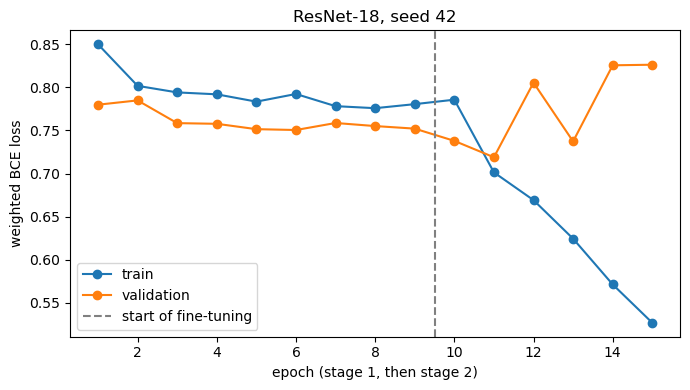

,epoch,train_loss,val_loss,stage,step
0,1,0.8499,0.7798,1,1
1,2,0.8016,0.7848,1,2
2,3,0.7940,0.7584,1,3
3,4,0.7918,0.7576,1,4
4,5,0.7833,0.7514,1,5
5,6,0.7922,0.7504,1,6
6,7,0.7781,0.7586,1,7
7,8,0.7757,0.7550,1,8
8,9,0.7804,0.7520,1,9
9,1,0.7856,0.7378,2,10


,TP,FP,TN,FN,accuracy,sensitivity,specificity,precision,F1,ROC-AUC,PR-AUC
MLP baseline (D),664.0,846.0,2387.0,227.0,0.7398,0.7452,0.7383,0.4397,0.5531,0.8074,0.5070
ResNet-18 stage 1: frozen feature extractor,686.0,750.0,2483.0,205.0,0.7684,0.7699,0.7680,0.4777,0.5896,0.8439,0.5873
ResNet-18 stage 2: layer4 fine-tuned,697.0,695.0,2538.0,194.0,0.7844,0.7823,0.7850,0.5007,0.6106,0.8659,0.6473


In [32]:
r = cnn[42]
h = pd.concat([r["h1"].assign(stage=1), r["h2"].assign(stage=2)], ignore_index=True)
h["step"] = np.arange(1, len(h) + 1)
plt.figure(figsize=(7, 4))
plt.plot(h["step"], h["train_loss"], marker="o", label="train")
plt.plot(h["step"], h["val_loss"], marker="o", label="validation")
plt.axvline(len(r["h1"]) + 0.5, color="grey", linestyle="--", label="start of fine-tuning")
plt.xlabel("epoch (stage 1, then stage 2)"); plt.ylabel("weighted BCE loss")
plt.title("ResNet-18, seed 42"); plt.legend(); plt.tight_layout(); plt.show()
display(h.round(4))

stage_table = pd.DataFrame({
    "MLP baseline (D)": metrics(best["y"], best["p"]),
    "ResNet-18 stage 1: frozen feature extractor": metrics(r["y"], r["p1"]),
    "ResNet-18 stage 2: layer4 fine-tuned": metrics(r["y"], r["p2"]),
}).T
display(stage_table.round(4))

### E5: three seeds, CNN versus baseline

The full two-stage pipeline is repeated with seeds 42, 43 and 44, and the selected baseline configuration from Part D is retrained with the same three seeds. For each run, ROC-AUC (the primary metric) is reported on the validation and test splits. The models are final at this point, so no setting is chosen on the test split. The mean and standard deviation across seeds measure run-to-run variation. The CNN's improvement over the baseline is compared with the largest seed standard deviation.

In [33]:
for s in SEEDS:
    if s not in cnn:
        start = time.time()
        cnn[s] = run_cnn(s)
        print(f"seed {s} finished in {(time.time() - start) / 60:.1f} min")

baseline_runs = {}
for s in SEEDS:
    set_seed(s)
    model, _, y, p = train_config(BEST_CFG, loss_weighted, seed=s)
    baseline_runs[s] = {"model": model, "y": y, "p": p}

rows = []
for name, runs, key in [("MLP baseline", baseline_runs, "p"), ("ResNet-18 fine-tuned", cnn, "p2")]:
    for s in SEEDS:
        _, p_test_s = predict(runs[s]["model"], test_loader)
        rows.append({"model": name, "seed": s,
                     "val ROC-AUC": roc_auc_score(runs[s]["y"], runs[s][key]),
                     "test ROC-AUC": roc_auc_score(test_img["Target"].values, p_test_s)})
seed_table = pd.DataFrame(rows)
display(seed_table.round(4))
seed_summary = seed_table.groupby("model")[["val ROC-AUC", "test ROC-AUC"]].agg(["mean", "std"])
display(seed_summary.round(4))

for split in ["val ROC-AUC", "test ROC-AUC"]:
    gap = seed_summary.loc["ResNet-18 fine-tuned", (split, "mean")] - seed_summary.loc["MLP baseline", (split, "mean")]
    sd = seed_summary.loc[:, (split, "std")].max()
    print(f"{split}: CNN - baseline = {gap:+.4f}; largest seed SD = {sd:.4f}; gap / SD = {gap / sd:.1f}")

seed 43 finished in 3.1 min
seed 44 finished in 2.7 min


,model,seed,val ROC-AUC,test ROC-AUC
0,MLP baseline,42,0.8074,0.8153
1,MLP baseline,43,0.8102,0.8200
2,MLP baseline,44,0.8049,0.8167
3,ResNet-18 fine-tuned,42,0.8659,0.8687
4,ResNet-18 fine-tuned,43,0.8622,0.8595
5,ResNet-18 fine-tuned,44,0.8665,0.8665


val ROC-AUC         test ROC-AUC        
                            mean     std         mean     std
model                                                        
MLP baseline              0.8075  0.0027       0.8173  0.0024
ResNet-18 fine-tuned      0.8649  0.0023       0.8649  0.0048

val ROC-AUC: CNN - baseline = +0.0574; largest seed SD = 0.0027; gap / SD = 21.3
test ROC-AUC: CNN - baseline = +0.0476; largest seed SD = 0.0048; gap / SD = 9.9


### Headline model

The seed-42 fine-tuned ResNet-18 is the headline model. Its weights and its validation and test predictions are saved to `outputs/` for threshold selection and calibration (Part F) and for Grad-CAM (Part G).

In [34]:
headline = cnn[42]["model"]
_, p_test_cnn = predict(headline, test_loader)
val_pred_cnn = pd.DataFrame({"patientId": val_img["patientId"].values, "Target": cnn[42]["y"], "p": cnn[42]["p2"]})
test_pred_cnn = pd.DataFrame({"patientId": test_img["patientId"].values, "Target": test_img["Target"].values, "p": p_test_cnn})
val_pred_cnn.to_csv("../outputs/val_pred_cnn.csv", index=False)
test_pred_cnn.to_csv("../outputs/test_pred_cnn.csv", index=False)
torch.save(headline.state_dict(), "../outputs/resnet18_seed42.pt")
print("saved seed-42 ResNet-18 weights and its validation/test predictions to ../outputs/")

saved seed-42 ResNet-18 weights and its validation/test predictions to ../outputs/


### E: interpretation


The pretrained ResNet-18 clearly performed better than my MLP baseline. Using frozen ImageNet features already improved the validation ROC-AUC from 0.807 to 0.844, and fine-tuning the final convolutional block increased it further to 0.866, showing that ImageNet features transfer reasonably well to chest X-rays and benefit from further adaptation. During stage 1, the training and validation losses stayed close and eventually flattened, suggesting underfitting. After fine-tuning, training loss continued to decrease while validation loss started to increase, showing overfitting, so early stopping restored the best model. Across three seeds, the fine-tuned CNN achieved a mean ROC-AUC of 0.8649 on both validation and test sets, compared with 0.8075 and 0.8173 for the MLP. This improvement was much larger than the variation between seeds. However, some of the performance may still come from differences in acquisition view rather than the lung opacity itself, which I investigate further using within-view analysis and Grad-CAM in Part G.

### E6: self-tests (exploratory, validation only)

I ran two additional experiments on the validation set to check some of my modelling choices. First, I tested whether giving ResNet three different versions of each X-ray—original, contrast-enhanced, and gamma-corrected—as RGB channels performed better than using a single grayscale channel. Second, I trained the same ResNet-18 from scratch without ImageNet pretraining to see how much the pretrained weights helped. Both experiments used seed 42 and the test set was not used, so they were exploratory checks and did not change my final model.

In [35]:
class ResNetVariant(ResNetCXR):
    def __init__(self, in_channels=1, pretrained=True):
        nn.Module.__init__(self)
        net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        if in_channels == 1:
            summed = net.conv1.weight.detach().sum(dim=1, keepdim=True)
            net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            if pretrained:
                net.conv1.weight.data.copy_(summed)
        net.fc = nn.Linear(net.fc.in_features, 1)
        self.net = net
        self.trainable = list(dict(net.named_children()))

In [36]:
from skimage.exposure import equalize_adapthist

CLAHE_CACHE = Path(f"../outputs/images_{IMG_SIZE}_clahe.npy")

def clahe_u8(img):
    return (equalize_adapthist(img, clip_limit=0.01) * 255).round().astype(np.uint8)

if CLAHE_CACHE.exists():
    X_clahe = np.load(CLAHE_CACHE)
else:
    with ThreadPoolExecutor(max_workers=8) as pool:
        X_clahe = np.stack(list(pool.map(clahe_u8, X)))
    np.save(CLAHE_CACHE, X_clahe)
assert X_clahe.shape == X.shape and X_clahe.dtype == np.uint8

vs = np.zeros(3); vs2 = np.zeros(3)
for start in range(0, len(tr_rows), 1000):
    raw = X[tr_rows[start:start + 1000]].astype(np.float64) / 255
    views = [raw, X_clahe[tr_rows[start:start + 1000]].astype(np.float64) / 255, np.sqrt(raw)]
    vs += [v.sum() for v in views]
    vs2 += [(v ** 2).sum() for v in views]
n_px = len(tr_rows) * IMG_SIZE * IMG_SIZE
VIEW_MEAN = torch.tensor(vs / n_px, dtype=torch.float32).view(3, 1, 1)
VIEW_STD = torch.tensor(np.sqrt(vs2 / n_px - (vs / n_px) ** 2), dtype=torch.float32).view(3, 1, 1)
print("training-split channel means (raw, CLAHE, gamma 0.5):", VIEW_MEAN.flatten().numpy().round(4))
print("training-split channel stds  (raw, CLAHE, gamma 0.5):", VIEW_STD.flatten().numpy().round(4))

class CXR3ViewDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.rows = row_of[frame["patientId"]].values
        self.y = frame["Target"].values.astype("float32")
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        raw = torch.from_numpy(X[self.rows[i]]).float().div(255)
        clahe = torch.from_numpy(X_clahe[self.rows[i]]).float().div(255)
        x = torch.stack([raw, clahe, raw.sqrt()])
        if self.transform is not None:
            x = self.transform(x)
        x = (x - VIEW_MEAN) / VIEW_STD
        return x, torch.tensor(self.y[i])

example = CXR3ViewDataset(tr_img)[0][0]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, channel, title in zip(axes, example, ["R: raw", "G: CLAHE", "B: gamma 0.5"]):
    ax.imshow(channel, cmap="gray")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

training-split channel means (raw, CLAHE, gamma 0.5): [0.4903 0.5628 0.6631]
training-split channel stds  (raw, CLAHE, gamma 0.5): [0.247  0.2761 0.225 ]


[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


In [37]:
start = time.time()
set_seed(42)
train3_loader = DataLoader(CXR3ViewDataset(tr_img, transform=train_aug), batch_size=CNN_BATCH, shuffle=True,
                           num_workers=WORKERS, pin_memory=True, generator=torch.Generator().manual_seed(42))
val3_loader = DataLoader(CXR3ViewDataset(val_img), batch_size=256, num_workers=WORKERS)
model3 = ResNetVariant(in_channels=3, pretrained=True)
model3.set_stage(1)
model3, h3_stage1 = fit(model3, train3_loader, val3_loader, loss_weighted, **STAGE1)
model3.set_stage(2)
model3, h3_stage2 = fit(model3, train3_loader, val3_loader, loss_weighted, **STAGE2)
y3, p3 = predict(model3, val3_loader)
print(f"self-test 1 finished in {(time.time() - start) / 60:.1f} min; validation ROC-AUC {roc_auc_score(y3, p3):.4f}")

self-test 1 finished in 5.1 min; validation ROC-AUC 0.8622


In [38]:
start = time.time()
set_seed(42)
model0 = ResNetVariant(in_channels=1, pretrained=False)
model0, h0 = fit(model0, make_cnn_train_loader(42), val_loader, loss_weighted, lr=1e-3, max_epochs=20, patience=4)
y0, p0 = predict(model0, val_loader)
print(f"self-test 2 finished in {(time.time() - start) / 60:.1f} min; validation ROC-AUC {roc_auc_score(y0, p0):.4f}")

self-test 2 finished in 3.9 min; validation ROC-AUC 0.8631


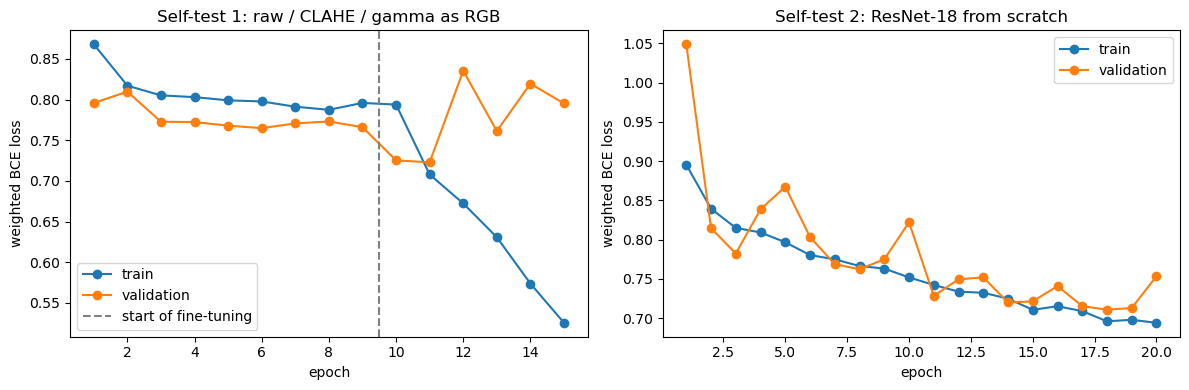

,TP,FP,TN,FN,accuracy,sensitivity,specificity,precision,F1,ROC-AUC,PR-AUC
Headline: 1-channel ImageNet ResNet-18 (seed 42),697.0,695.0,2538.0,194.0,0.7844,0.7823,0.7850,0.5007,0.6106,0.8659,0.6473
Self-test 1: 3-view RGB ImageNet ResNet-18,712.0,755.0,2478.0,179.0,0.7735,0.7991,0.7665,0.4853,0.6039,0.8622,0.6292
Self-test 2: ResNet-18 from scratch,693.0,701.0,2532.0,198.0,0.7820,0.7778,0.7832,0.4971,0.6066,0.8631,0.6496


headline validation ROC-AUC over 3 seeds: 0.8649 ± 0.0023
self-test 1 difference: -0.0027
self-test 2 difference: -0.0018


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
h3 = pd.concat([h3_stage1, h3_stage2], ignore_index=True)
for ax, hist, title, boundary in [(axes[0], h3, "Self-test 1: raw / CLAHE / gamma as RGB", len(h3_stage1)),
                                  (axes[1], h0, "Self-test 2: ResNet-18 from scratch", None)]:
    steps = np.arange(1, len(hist) + 1)
    ax.plot(steps, hist["train_loss"], marker="o", label="train")
    ax.plot(steps, hist["val_loss"], marker="o", label="validation")
    if boundary:
        ax.axvline(boundary + 0.5, color="grey", linestyle="--", label="start of fine-tuning")
    ax.set_xlabel("epoch"); ax.set_ylabel("weighted BCE loss"); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

selftest_table = pd.DataFrame({
    "Headline: 1-channel ImageNet ResNet-18 (seed 42)": metrics(cnn[42]["y"], cnn[42]["p2"]),
    "Self-test 1: 3-view RGB ImageNet ResNet-18": metrics(y3, p3),
    "Self-test 2: ResNet-18 from scratch": metrics(y0, p0),
}).T
display(selftest_table.round(4))
headline_val = seed_summary.loc["ResNet-18 fine-tuned", ("val ROC-AUC", "mean")]
headline_sd = seed_summary.loc["ResNet-18 fine-tuned", ("val ROC-AUC", "std")]
print(f"headline validation ROC-AUC over 3 seeds: {headline_val:.4f} ± {headline_sd:.4f}")
print(f"self-test 1 difference: {roc_auc_score(y3, p3) - headline_val:+.4f}")
print(f"self-test 2 difference: {roc_auc_score(y0, p0) - headline_val:+.4f}")

### E6: self-test interpretation

Neither self-test clearly improved on my main ResNet-18 model. Using the raw, CLAHE-enhanced, and gamma-corrected images as three RGB channels gave a similar ROC-AUC (0.862 vs. 0.866), suggesting that these contrast transformations did not add useful information beyond the original image. Surprisingly, training ResNet-18 from scratch also achieved a similar ROC-AUC (0.863), although it took longer to converge than the pretrained model. This suggests that ImageNet pretraining mainly helped with faster training rather than clearly improving final performance in this dataset. Since both experiments were run with only one seed on the validation set, I interpret these results as showing no clear difference rather than one approach being better.

# Part F

### Saved predictions

Part F uses only the probabilities saved in Parts D and E, from the selected MLP baseline and the headline ResNet-18 (both seed 42), so no model is retrained. The trivial baseline always predicts negative. The assertions check that the saved rows match the validation and test examinations in the same order.

In [40]:
import json
from sklearn.metrics import roc_curve, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve

y_val = val_img["Target"].values
y_test = test_img["Target"].values
preds = {}
for name, tag in [("MLP baseline", "baseline"), ("ResNet-18", "cnn")]:
    v = pd.read_csv(f"../outputs/val_pred_{tag}.csv")
    t = pd.read_csv(f"../outputs/test_pred_{tag}.csv")
    assert (v["patientId"].values == val_img["patientId"].values).all() and (v["Target"].values == y_val).all()
    assert (t["patientId"].values == test_img["patientId"].values).all() and (t["Target"].values == y_test).all()
    preds[name] = {"val": v["p"].values, "test": t["p"].values}
print({name: {split: len(p) for split, p in pr.items()} for name, pr in preds.items()})

{'MLP baseline': {'val': 4124, 'test': 4996}, 'ResNet-18': {'val': 4124, 'test': 4996}}


### F4, step 1: threshold sweep on the validation split

Before any threshold is chosen, the table shows how sensitivity, specificity, precision and accuracy change as the decision threshold moves from 0.10 to 0.95. Only the validation split is used. Lower thresholds flag more examinations as positive, which raises sensitivity and lowers specificity; higher thresholds do the opposite.

In [41]:
sweep = []
for name, pr in preds.items():
    for t in np.round(np.arange(0.10, 0.96, 0.05), 2):
        m = metrics(y_val, pr["val"], t)
        sweep.append({"model": name, "threshold": t, "sensitivity": m["sensitivity"],
                      "specificity": m["specificity"], "precision": m["precision"], "accuracy": m["accuracy"]})
sweep = pd.DataFrame(sweep)
display(sweep.pivot(index="threshold", columns="model",
                    values=["sensitivity", "specificity", "precision", "accuracy"]).round(3))

sensitivity            specificity              precision  \
model     MLP baseline ResNet-18 MLP baseline ResNet-18 MLP baseline   
threshold                                                              
0.10             0.988     0.966        0.172     0.458        0.247   
0.15             0.973     0.945        0.273     0.526        0.269   
0.20             0.957     0.930        0.366     0.577        0.294   
0.25             0.943     0.911        0.437     0.616        0.316   
0.30             0.907     0.896        0.509     0.659        0.337   
0.35             0.872     0.875        0.570     0.694        0.359   
0.40             0.825     0.843        0.633     0.727        0.382   
0.45             0.787     0.807        0.687     0.756        0.409   
0.50             0.745     0.782        0.738     0.785        0.440   
0.55             0.686     0.747        0.783     0.810        0.466   
0.60             0.617     0.708        0.817     0.836        0.482   
0.65             0.533     0.667        0.854     0.861        0.502   
0.70             0.446     0.629        0.892     0.881        0.533   
0.75             0.347     0.563        0.930     0.906        0.578   
0.80             0.229     0.504        0.961     0.928        0.618   
0.85             0.107     0.428        0.983     0.951        0.629   
0.90             0.026     0.328        0.996     0.968        0.622   
0.95             0.006     0.202        0.999     0.986        0.714   

                        accuracy            
model     ResNet-18 MLP baseline ResNet-18  
threshold                                   
0.10          0.330        0.348     0.568  
0.15          0.355        0.424     0.616  
0.20          0.377        0.494     0.653  
0.25          0.395        0.546     0.680  
0.30          0.420        0.595     0.710  
0.35          0.441        0.635     0.734  
0.40          0.459        0.674     0.752  
0.45          0.477        0.709     0.767  
0.50          0.501        0.740     0.784  
0.55          0.520        0.762     0.797  
0.60          0.543        0.774     0.808  
0.65          0.568        0.785     0.819  
0.70          0.593        0.796     0.826  
0.75          0.624        0.804     0.832  
0.80          0.658        0.803     0.836  
0.85          0.708        0.793     0.838  
0.90          0.741        0.786     0.830  
0.95          0.800        0.785     0.817

### F4, step 2: choosing and freezing the two operating thresholds

I selected separate thresholds for each model using only the validation set. For screening, I chose the highest threshold that still achieved at least 90% sensitivity, so most positive cases were detected while reducing unnecessary false positives. For the high-specificity setting, I chose the lowest threshold that achieved at least 95% specificity, limiting false positives while detecting as many positive cases as possible. I kept 0.5 as a reference threshold. These thresholds were fixed before evaluating the test set, so the test data did not influence their selection.

In [42]:
def pick_thresholds(y, p, min_sens=0.90, min_spec=0.95):
    fpr, tpr, thr = roc_curve(y, p, drop_intermediate=False)
    return {"screening": float(thr[tpr >= min_sens].max()),
            "high-specificity": float(thr[(1 - fpr) >= min_spec].min())}

THRESHOLDS = {}
for name, pr in preds.items():
    THRESHOLDS[name] = {"default 0.5": 0.5, **pick_thresholds(y_val, pr["val"])}

rows = []
for name, pr in preds.items():
    for op, t in THRESHOLDS[name].items():
        m = metrics(y_val, pr["val"], t)
        rows.append({"model": name, "operating point": op, "threshold": t,
                     "val sensitivity": m["sensitivity"], "val specificity": m["specificity"]})
display(pd.DataFrame(rows).round(4))

with open("../outputs/frozen_thresholds.json", "w") as f:
    json.dump(THRESHOLDS, f, indent=1)
print("thresholds frozen (chosen on validation only) and saved to ../outputs/frozen_thresholds.json")

,model,operating point,threshold,val sensitivity,val specificity
0,MLP baseline,default 0.5,0.5000,0.7452,0.7383
1,MLP baseline,screening,0.3179,0.9001,0.5311
2,MLP baseline,high-specificity,0.7805,0.2817,0.9502
3,ResNet-18,default 0.5,0.5000,0.7823,0.7850
4,ResNet-18,screening,0.2823,0.9001,0.6443
5,ResNet-18,high-specificity,0.8457,0.4366,0.9502


thresholds frozen (chosen on validation only) and saved to ../outputs/frozen_thresholds.json


### F1 and F2: comparison on the test split

One table compares the trivial baseline, the MLP baseline and the ResNet-18 on the same test split, with the same metrics computed from the predicted probabilities at each frozen threshold:

- confusion-matrix counts (TP, FP, TN, FN);
- accuracy, sensitivity, specificity, precision and F1;
- the threshold-free ROC-AUC and PR-AUC (average precision).

The confusion matrices at the two frozen thresholds follow the table.

In [43]:
OPS = ["default 0.5", "screening", "high-specificity"]
rows = [{"model": "Trivial (always negative)", "operating point": "-", "threshold": np.nan,
         **metrics(y_test, np.zeros(len(y_test)))}]
for name, pr in preds.items():
    for op in OPS:
        rows.append({"model": name, "operating point": op, "threshold": THRESHOLDS[name][op],
                     **metrics(y_test, pr["test"], THRESHOLDS[name][op])})
comparison = pd.DataFrame(rows).set_index(["model", "operating point"])
display(comparison.round(4))
comparison.to_csv("../outputs/test_comparison_table.csv")

threshold   TP    FP    TN    FN  \
model                     operating point                                      
Trivial (always negative) -                       NaN    0     0  3946  1050   
MLP baseline              default 0.5          0.5000  797   998  2948   253   
                          screening            0.3179  928  1799  2147   122   
                          high-specificity     0.7805  240   170  3776   810   
ResNet-18                 default 0.5          0.5000  807   793  3153   243   
                          screening            0.2823  933  1322  2624   117   
                          high-specificity     0.8457  436   154  3792   614   

                                            accuracy  sensitivity  \
model                     operating point                           
Trivial (always negative) -                   0.7898       0.0000   
MLP baseline              default 0.5         0.7496       0.7590   
                          screening           0.6155       0.8838   
                          high-specificity    0.8038       0.2286   
ResNet-18                 default 0.5         0.7926       0.7686   
                          screening           0.7120       0.8886   
                          high-specificity    0.8463       0.4152   

                                            specificity  precision      F1  \
model                     operating point                                    
Trivial (always negative) -                      1.0000        NaN  0.0000   
MLP baseline              default 0.5            0.7471     0.4440  0.5603   
                          screening              0.5441     0.3403  0.4914   
                          high-specificity       0.9569     0.5854  0.3288   
ResNet-18                 default 0.5            0.7990     0.5044  0.6091   
                          screening              0.6650     0.4137  0.5646   
                          high-specificity       0.9610     0.7390  0.5317   

                                            ROC-AUC  PR-AUC  
model                     operating point                    
Trivial (always negative) -                  0.5000  0.2102  
MLP baseline              default 0.5        0.8153  0.4983  
                          screening          0.8153  0.4983  
                          high-specificity   0.8153  0.4983  
ResNet-18                 default 0.5        0.8687  0.6709  
                          screening          0.8687  0.6709  
                          high-specificity   0.8687  0.6709

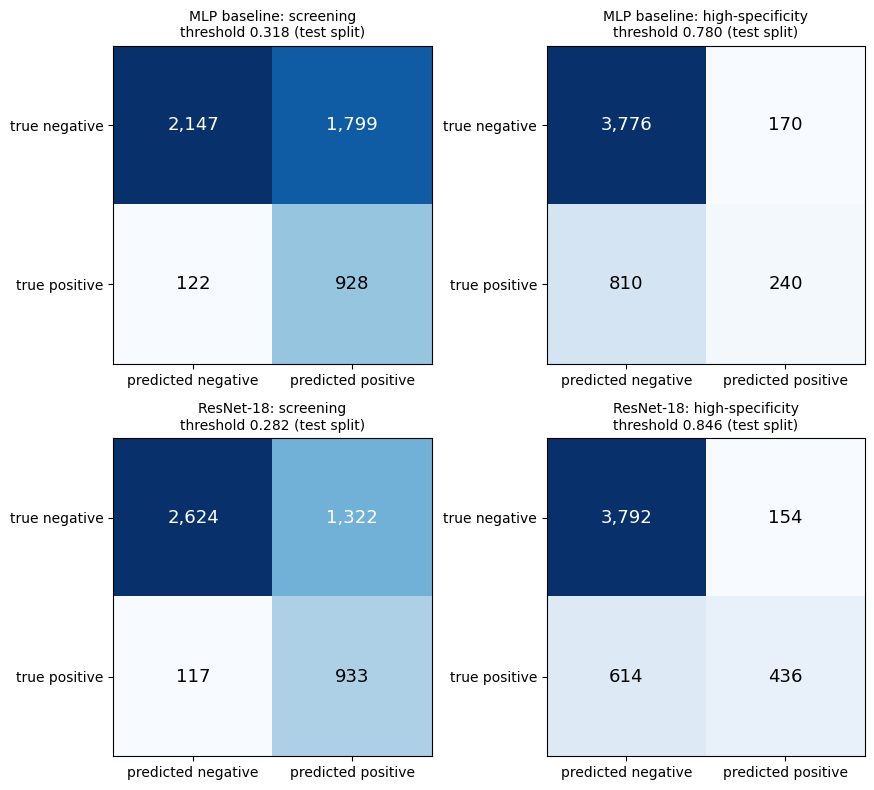

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for r, name in enumerate(preds):
    for c, op in enumerate(["screening", "high-specificity"]):
        m = metrics(y_test, preds[name]["test"], THRESHOLDS[name][op])
        cm = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
        ax = axes[r, c]
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_xticks([0, 1], ["predicted negative", "predicted positive"])
        ax.set_yticks([0, 1], ["true negative", "true positive"])
        ax.set_title(f"{name}: {op}\nthreshold {THRESHOLDS[name][op]:.3f} (test split)", fontsize=10)
plt.tight_layout(); plt.show()

### F3: ROC and precision-recall curves (test split)

I plotted the ROC and precision-recall curves for both models on the test set and marked the screening and high-specificity operating points. Since only about 21% of the test images were positive, I consider the precision-recall curve more informative here. ROC can make performance look relatively strong because the false-positive rate is calculated using the much larger negative class. In contrast, precision is directly reduced by every false positive, so the PR curve gives a clearer picture of how reliable the model’s positive predictions are.

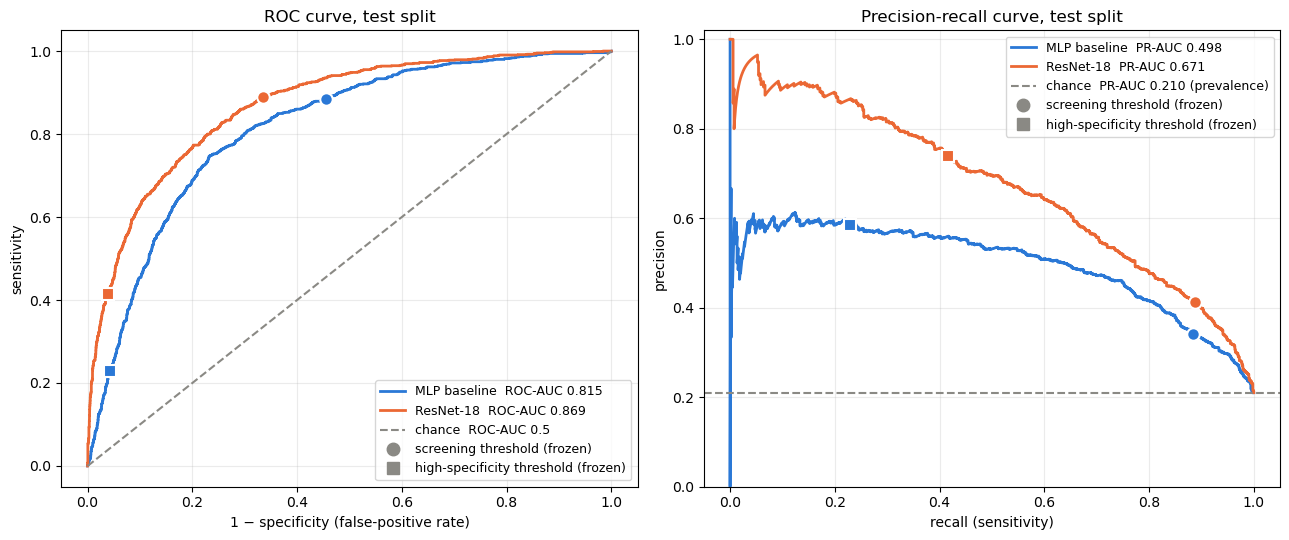

In [45]:
COLORS = {"MLP baseline": "#2a78d6", "ResNet-18": "#eb6834"}
GREY = "#8a8984"
MARKERS = {"screening": "o", "high-specificity": "s"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, pr in preds.items():
    fpr, tpr, _ = roc_curve(y_test, pr["test"])
    precision, recall, _ = precision_recall_curve(y_test, pr["test"])
    axes[0].plot(fpr, tpr, color=COLORS[name], lw=2,
                 label=f"{name}  ROC-AUC {roc_auc_score(y_test, pr['test']):.3f}")
    axes[1].plot(recall, precision, color=COLORS[name], lw=2,
                 label=f"{name}  PR-AUC {average_precision_score(y_test, pr['test']):.3f}")
    for op, marker in MARKERS.items():
        m = metrics(y_test, pr["test"], THRESHOLDS[name][op])
        axes[0].plot(1 - m["specificity"], m["sensitivity"], marker=marker, ms=9, ls="none",
                     color=COLORS[name], mec="white", mew=1.5)
        axes[1].plot(m["sensitivity"], m["precision"], marker=marker, ms=9, ls="none",
                     color=COLORS[name], mec="white", mew=1.5)
axes[0].plot([0, 1], [0, 1], ls="--", lw=1.5, color=GREY, label="chance  ROC-AUC 0.5")
axes[1].axhline(y_test.mean(), ls="--", lw=1.5, color=GREY, label=f"chance  PR-AUC {y_test.mean():.3f} (prevalence)")
for op, marker in MARKERS.items():
    for ax in axes:
        ax.plot([], [], marker=marker, ms=9, ls="none", color=GREY, label=f"{op} threshold (frozen)")
axes[0].set(xlabel="1 − specificity (false-positive rate)", ylabel="sensitivity", title="ROC curve, test split")
axes[1].set(xlabel="recall (sensitivity)", ylabel="precision", title="Precision-recall curve, test split", ylim=(0, 1.02))
axes[0].legend(loc="lower right", fontsize=9)
axes[1].legend(loc="upper right", fontsize=9)
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### F5: reliability diagram and calibration

I used reliability diagrams and the Brier score to check whether the predicted probabilities were well calibrated. Good discrimination means the model ranks positive cases above negative ones, while good calibration means that the predicted probabilities reflect the actual frequency of positive cases. Because I trained both models with `pos_weight = 3.455`, their predicted probabilities were expected to be too high. I therefore applied a prior correction based only on the training-set class counts. This adjusts the probabilities without changing their ranking, so ROC-AUC remains unchanged, while the probabilities become more representative of the actual risk.

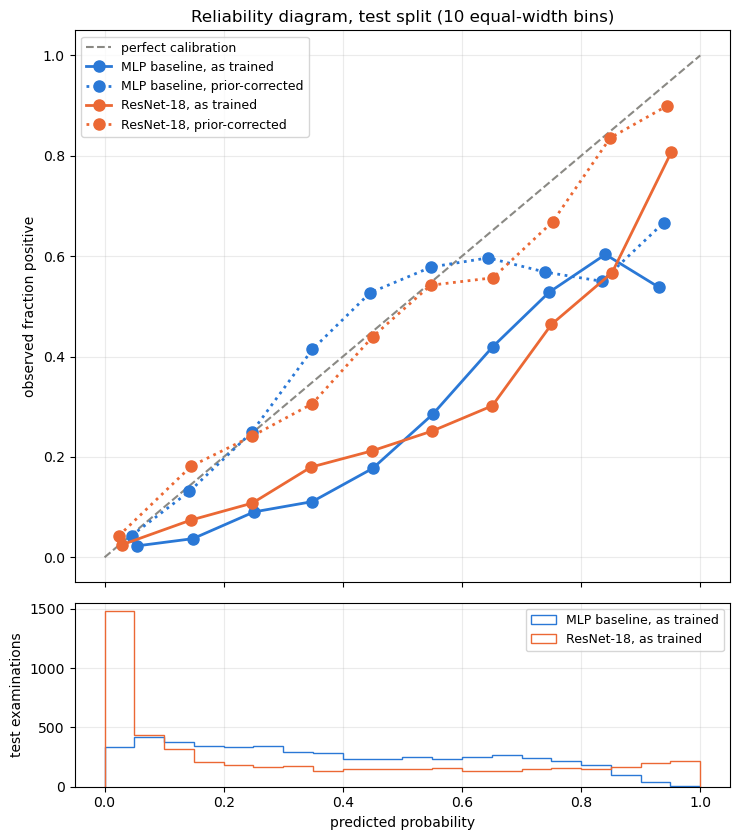

,model,probabilities,mean predicted,observed positive rate,Brier score,ROC-AUC
0,MLP baseline,as trained,0.3934,0.2102,0.1696,0.8153
1,MLP baseline,prior-corrected,0.2024,0.2102,0.1306,0.8153
2,ResNet-18,as trained,0.3374,0.2102,0.1390,0.8687
3,ResNet-18,prior-corrected,0.2067,0.2102,0.1088,0.8687


In [46]:
W = POS_WEIGHT.item()

def prior_correct(p):
    return p / (p + W * (1 - p))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 8.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.plot([0, 1], [0, 1], ls="--", lw=1.5, color=GREY, label="perfect calibration")
calibration_rows = []
for name, pr in preds.items():
    for version, p, style in [("as trained", pr["test"], "-"), ("prior-corrected", prior_correct(pr["test"]), ":")]:
        observed, predicted = calibration_curve(y_test, p, n_bins=10, strategy="uniform")
        ax1.plot(predicted, observed, ls=style, lw=2, marker="o", ms=8, color=COLORS[name], label=f"{name}, {version}")
        calibration_rows.append({"model": name, "probabilities": version, "mean predicted": p.mean(),
                                 "observed positive rate": y_test.mean(), "Brier score": brier_score_loss(y_test, p),
                                 "ROC-AUC": roc_auc_score(y_test, p)})
    ax2.hist(pr["test"], bins=np.linspace(0, 1, 21), histtype="step", lw=2, color=COLORS[name], label=f"{name}, as trained")
ax1.set(ylabel="observed fraction positive", title="Reliability diagram, test split (10 equal-width bins)")
ax1.legend(loc="upper left", fontsize=9); ax1.grid(alpha=0.25)
ax2.set(xlabel="predicted probability", ylabel="test examinations")
ax2.legend(loc="upper right", fontsize=9); ax2.grid(alpha=0.25)
plt.tight_layout(); plt.show()
display(pd.DataFrame(calibration_rows).round(4))

### F: interpretation


| model | screening threshold | validation sensitivity / specificity | high-specificity threshold | validation sensitivity / specificity |
|---|---|---|---|---|
| ResNet-18 | 0.282 | 0.900 / 0.644 | 0.846 | 0.437 / 0.950 |
| MLP baseline | 0.318 | - | 0.780 | - |


I selected the operating thresholds using only the validation set and then applied them unchanged to the test set. At the screening threshold, both models achieved high sensitivity (around 0.89), but the ResNet-18 produced substantially fewer false positives than the MLP. At the high-specificity threshold, both achieved about 0.96 specificity, but the ResNet-18 detected considerably more positive cases. Overall, the ResNet-18 showed better discrimination, with a ROC-AUC of 0.869 and PR-AUC of 0.671 compared with 0.815 and 0.498 for the MLP. I also found that the weighted loss caused both models to overestimate the probability of a positive case, so the original probabilities were poorly calibrated. After correcting for this weighting effect, calibration and Brier scores improved without changing ROC-AUC. This shows the difference between discrimination—how well the model ranks positive and negative cases—and calibration—how accurately its predicted probabilities represent the actual risk.

# Part G

### Setup

Part G analyses the headline ResNet-18 (seed 42) on the test split. The model is reloaded from its saved weights, and the assertion checks that it reproduces the saved test predictions. Each test examination gets its view position (AP or PA) from the header table built in A4. Examples are grouped at the frozen screening threshold chosen in Part F.

In [47]:
headline_model = ResNetCXR()
headline_model.load_state_dict(torch.load("../outputs/resnet18_seed42.pt", map_location="cpu"))
headline_model.to(DEVICE).eval()

p_cnn = preds["ResNet-18"]["test"]
p_mlp = preds["MLP baseline"]["test"]
_, p_check = predict(headline_model, test_loader)
assert np.allclose(p_check, p_cnn, atol=1e-3), "reloaded model does not reproduce the saved predictions"

test_view = test_img[["patientId"]].merge(headers[["patientId", "ViewPosition"]], on="patientId",
                                           how="left", validate="one_to_one")["ViewPosition"].values
assert pd.notna(test_view).all()
T_SCREEN = THRESHOLDS["ResNet-18"]["screening"]
print(f"headline ResNet-18 reloaded; screening threshold {T_SCREEN:.3f}; test views: {dict(pd.Series(test_view).value_counts())}")

headline ResNet-18 reloaded; screening threshold 0.282; test views: {'PA': np.int64(2742), 'AP': np.int64(2254)}


### G1: example predictions

At the screening threshold, I divided the test predictions into true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN). I randomly selected two examples from each group using a fixed seed rather than choosing them manually. For positive cases, I also show the radiologists’ bounding boxes to indicate the location of the annotated abnormality.

In [48]:
category = np.select([(p_cnn >= T_SCREEN) & (y_test == 1), (p_cnn < T_SCREEN) & (y_test == 0),
                      (p_cnn >= T_SCREEN) & (y_test == 0), (p_cnn < T_SCREEN) & (y_test == 1)],
                     ["TP", "TN", "FP", "FN"], default="")
assert (category != "").all()
print(pd.Series(category).value_counts().reindex(["TP", "TN", "FP", "FN"]))

rng = np.random.default_rng(SEED)
examples = [(cat, int(i)) for cat in ["TP", "TN", "FP", "FN"]
            for i in rng.choice(np.where(category == cat)[0], size=2, replace=False)]

boxes_test = test.dropna(subset=["x"])
SCALE = IMG_SIZE / 1024

def show_example(ax, i, overlay=None):
    pid = test_img["patientId"].values[i]
    ax.imshow(X[row_of[pid]], cmap="gray", vmin=0, vmax=255)
    if overlay is not None:
        ax.imshow(overlay, cmap="inferno", alpha=0.45, vmin=0, vmax=1)
    for _, b in boxes_test[boxes_test["patientId"] == pid].iterrows():
        ax.add_patch(Rectangle((b["x"] * SCALE, b["y"] * SCALE), b["width"] * SCALE, b["height"] * SCALE,
                               fill=False, edgecolor="#1baf7a", lw=1.5))
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for ax, (cat, i) in zip(axes.T.ravel(), examples):
    show_example(ax, i)
    ax.set_title(f"{cat} | label {y_test[i]} | p = {p_cnn[i]:.2f} | {test_view[i]}", fontsize=9)
plt.tight_layout(); plt.show()

TP     933
TN    2624
FP    1322
FN     117
Name: count, dtype: int64


[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


### G2: subgroup performance, AP versus PA

I evaluated both models separately on AP and PA chest X-rays to check whether their performance was partly driven by differences in acquisition view. For each subgroup, I calculated ROC-AUC, PR-AUC, sensitivity, and specificity using the previously fixed thresholds. If performance within AP and PA images is clearly lower than the overall performance, this would suggest that the model is partly using differences between the two views, rather than only detecting pneumonia-related features.

In [49]:
def bootstrap_auc(y, p, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_boot):
        b = rng.integers(0, len(y), len(y))
        if y[b].min() != y[b].max():
            aucs.append(roc_auc_score(y[b], p[b]))
    return np.percentile(aucs, [2.5, 97.5])

rows = []
for group in ["all", "AP", "PA"]:
    mask = np.ones(len(y_test), bool) if group == "all" else (test_view == group)
    yg = y_test[mask]
    for name, p in [("ResNet-18", p_cnn), ("MLP baseline", p_mlp)]:
        lo, hi = bootstrap_auc(yg, p[mask])
        ms = metrics(yg, p[mask], THRESHOLDS[name]["screening"])
        mh = metrics(yg, p[mask], THRESHOLDS[name]["high-specificity"])
        rows.append({"subgroup": group, "model": name, "n": int(mask.sum()), "positives": int(yg.sum()),
                     "prevalence": yg.mean(), "ROC-AUC": roc_auc_score(yg, p[mask]), "95% CI": f"{lo:.3f}-{hi:.3f}",
                     "PR-AUC": average_precision_score(yg, p[mask]),
                     "screening sens": ms["sensitivity"], "screening spec": ms["specificity"],
                     "high-spec sens": mh["sensitivity"], "high-spec spec": mh["specificity"]})
subgroup_table = pd.DataFrame(rows).set_index(["subgroup", "model"])
display(subgroup_table.round(3))
print(f"view alone on the test split (AP = predict positive): ROC-AUC {roc_auc_score(y_test, test_view == 'AP'):.3f}")

n  positives  prevalence  ROC-AUC       95% CI  \
subgroup model                                                             
all      ResNet-18     4996       1050       0.210    0.869  0.858-0.881   
         MLP baseline  4996       1050       0.210    0.815  0.801-0.830   
AP       ResNet-18     2254        835       0.370    0.820  0.803-0.838   
         MLP baseline  2254        835       0.370    0.728  0.708-0.749   
PA       ResNet-18     2742        215       0.078    0.801  0.767-0.832   
         MLP baseline  2742        215       0.078    0.747  0.711-0.781   

                       PR-AUC  screening sens  screening spec  high-spec sens  \
subgroup model                                                                  
all      ResNet-18      0.671           0.889           0.665           0.415   
         MLP baseline   0.498           0.884           0.544           0.229   
AP       ResNet-18      0.733           0.951           0.374           0.499   
         MLP baseline   0.562           0.956           0.226           0.280   
PA       ResNet-18      0.333           0.647           0.828           0.088   
         MLP baseline   0.196           0.605           0.723           0.028   

                       high-spec spec  
subgroup model                         
all      ResNet-18              0.961  
         MLP baseline           0.957  
AP       ResNet-18              0.899  
         MLP baseline           0.897  
PA       ResNet-18              0.996  
         MLP baseline           0.991

view alone on the test split (AP = predict positive): ROC-AUC 0.718


### G3: Grad-CAM

I used Grad-CAM to see which parts of each X-ray contributed most to the model’s pneumonia prediction. I generated the heatmaps from the last residual block (`layer4[-1]`) because it contains the model’s most task-specific features while still preserving spatial information. Brighter regions indicate areas that contributed more strongly to the pneumonia score. Since this layer produces a 7×7 feature map, the Grad-CAM heatmaps highlight broad regions rather than precise abnormalities. I examined both correct and incorrect predictions (TP, TN, FP, and FN) to understand what the model was focusing on and whether it might be using irrelevant features.

In [50]:
target_layer = headline_model.net.layer4[-1]

def grad_cam(model, x):
    store = {}
    def forward_hook(module, inputs, output):
        store["act"] = output
        output.register_hook(lambda g: store.__setitem__("grad", g))
    hook = target_layer.register_forward_hook(forward_hook)
    model.eval()
    model.zero_grad()
    logits = model(x.to(DEVICE)).squeeze(1)
    logits.sum().backward()
    hook.remove()
    weights = store["grad"].mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * store["act"]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)[:, 0]
    cam = cam / cam.amax(dim=(1, 2), keepdim=True).clamp_min(1e-8)
    return cam.detach().cpu().numpy(), torch.sigmoid(logits).detach().cpu().numpy()

idx = [i for _, i in examples]
cams, probs = grad_cam(headline_model, torch.stack([test_ds[i][0] for i in idx]))
assert np.allclose(probs, p_cnn[idx], atol=1e-3)

fig, axes = plt.subplots(4, 4, figsize=(13, 13.5))
for k, (cat, i) in enumerate(examples):
    r, c = k // 2, (k % 2) * 2
    show_example(axes[r, c], i)
    axes[r, c].set_title(f"{cat} | label {y_test[i]} | p = {p_cnn[i]:.2f} | {test_view[i]}", fontsize=9)
    show_example(axes[r, c + 1], i, overlay=cams[k])
    axes[r, c + 1].set_title("Grad-CAM, layer4 (last block)", fontsize=9)
plt.tight_layout(); plt.show()

[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


### G4: lungs or shortcuts? A quantitative check

Since individual Grad-CAM images can be subjective, I also analysed the heatmaps across the entire test set. I measured how much attention fell near the image borders to check whether the model might be relying on markers or text, and I used a pointing-game test to see whether the hottest part of the heatmap fell inside the radiologists’ annotated pneumonia regions. These measurements give a more objective view of where the model focuses, although Grad-CAM alone cannot prove that those regions actually caused the prediction.

In [51]:
BORDER = 0.08
b = int(round(BORDER * IMG_SIZE))
ring = np.ones((IMG_SIZE, IMG_SIZE), bool)
ring[b:-b, b:-b] = False

box_masks = {}
for pid, g in boxes_test.groupby("patientId"):
    m = np.zeros((IMG_SIZE, IMG_SIZE), bool)
    for _, bx in g.iterrows():
        x0, y0 = int(bx["x"] * SCALE), int(bx["y"] * SCALE)
        x1, y1 = int(np.ceil((bx["x"] + bx["width"]) * SCALE)), int(np.ceil((bx["y"] + bx["height"]) * SCALE))
        m[y0:y1, x0:x1] = True
    box_masks[pid] = m
assert len(box_masks) == int(y_test.sum())

pids = test_img["patientId"].values
border_share = np.full(len(y_test), np.nan)
peak_in_ring = np.full(len(y_test), np.nan)
peak_in_box = np.full(len(y_test), np.nan)
box_area = np.full(len(y_test), np.nan)
for start in range(0, len(y_test), 64):
    batch = list(range(start, min(start + 64, len(y_test))))
    cams_b, _ = grad_cam(headline_model, torch.stack([test_ds[i][0] for i in batch]))
    for k, i in enumerate(batch):
        cam = cams_b[k]
        if cam.max() == 0:
            continue
        r, c = np.unravel_index(cam.argmax(), cam.shape)
        border_share[i] = cam[ring].sum() / cam.sum()
        peak_in_ring[i] = ring[r, c]
        if pids[i] in box_masks:
            peak_in_box[i] = box_masks[pids[i]][r, c]
            box_area[i] = box_masks[pids[i]].mean()

cam_stats = pd.DataFrame({"category": category, "view": test_view, "border share": border_share,
                          "peak in border ring": peak_in_ring, "peak in box": peak_in_box, "box area": box_area})
print(f"border ring = outer {BORDER:.0%} of width and height = {ring.mean():.1%} of the image area "
      f"(the border share expected if attention were spread evenly)")
print(f"images with an all-zero Grad-CAM (excluded): {int(np.isnan(border_share).sum())}")
display(cam_stats.groupby("category")[["border share", "peak in border ring"]].mean().reindex(["TP", "TN", "FP", "FN"]).round(3))
display(cam_stats.groupby("view")[["border share", "peak in border ring"]].mean().round(3))
positives = cam_stats.dropna(subset=["peak in box"])
display(positives.groupby("category")[["peak in box", "box area"]].agg(["mean", "size"]).round(3))
print(f"pointing game, all {len(positives)} positive test examinations: CAM peak inside a box "
      f"{positives['peak in box'].mean():.1%} of the time vs {positives['box area'].mean():.1%} expected by chance")

border ring = outer 8% of width and height = 29.6% of the image area (the border share expected if attention were spread evenly)
images with an all-zero Grad-CAM (excluded): 7


,border share,peak in border ring
category,,
TP,0.242,0.139
TN,0.588,0.892
FP,0.330,0.345
FN,0.540,0.793


,border share,peak in border ring
view,,
AP,0.346,0.369
PA,0.543,0.798


peak in box      box area     
                mean size     mean size
category                               
FN             0.000  116    0.045  116
TP             0.252  933    0.127  933

pointing game, all 1049 positive test examinations: CAM peak inside a box 22.4% of the time vs 11.8% expected by chance


### G: interpretation

**Prediction groups (G1).** At the screening threshold, the headline model gives the following counts on the test split:

- 933 true positives;
- 2,624 true negatives;
- 1,322 false positives;
- 117 false negatives.

The missed positives have much smaller annotated opacities than the detected ones. Their boxes cover on average 4.5% of the image, against 12.7% for true positives (G4 table). Small opacities are the hardest to see at 224×224 resolution.

**AP versus PA (G2).**

| test split | n | positives (prevalence) | ResNet-18 ROC-AUC (95% CI) | MLP ROC-AUC (95% CI) |
|---|---|---|---|---|
| all | 4,996 | 1,050 (0.210) | 0.869 (0.858-0.881) | 0.815 (0.801-0.830) |
| AP | 2,254 | 835 (0.370) | 0.820 (0.803-0.838) | 0.728 (0.708-0.749) |
| PA | 2,742 | 215 (0.078) | 0.801 (0.767-0.832) | 0.747 (0.711-0.781) |

I found that acquisition view explains part of the model’s overall performance. The ResNet-18 ROC-AUC dropped from 0.869 overall to 0.820 for AP and 0.801 for PA images, although it still performed well within both groups and remained better than the MLP. The same screening threshold also behaved differently between views, with much higher sensitivity for AP than PA images, suggesting that view-specific thresholds may be needed.

The Grad-CAM analysis showed that true-positive predictions mainly focused on the central chest, while false positives showed somewhat more attention near the image borders. For positive cases, the hottest Grad-CAM point fell inside a radiologist-annotated region 22.4% of the time, compared with 11.8% expected by chance. This suggests that the model is learning some relevant opacity information, but its localisation is fairly broad and it may also use contextual or border-related features. Overall, the model is not simply detecting the acquisition view or image borders, but both remain possible shortcut signals that should be considered when interpreting its performance.

# Bonus questions

### Bonus 1: prevalence shift and threshold transfer

I created two additional test sets with 10% and 40% positive prevalence to see how changing disease prevalence affects model performance. I did not retrain the ResNet-18 or change its screening threshold, so the model remained exactly the same. I compared sensitivity, specificity, precision, F1, ROC-AUC, NPV, and accuracy across the different prevalence levels. I also repeated the random subsampling 200 times to make sure the results were not dependent on one particular sample. This experiment shows which performance metrics remain stable and which change when the same model is used in populations with different disease prevalence.

In [52]:
p_shift = preds["ResNet-18"]["test"]
T_SHIFT = THRESHOLDS["ResNet-18"]["screening"]
pos_idx = np.where(y_test == 1)[0]
neg_idx = np.where(y_test == 0)[0]

def prevalence_subset(target, rng):
    if target < y_test.mean():
        n_keep = int(round(target / (1 - target) * len(neg_idx)))
        return np.concatenate([neg_idx, rng.choice(pos_idx, n_keep, replace=False)])
    n_keep = int(round((1 - target) / target * len(pos_idx)))
    return np.concatenate([pos_idx, rng.choice(neg_idx, n_keep, replace=False)])

def shift_metrics(idx):
    m = metrics(y_test[idx], p_shift[idx], T_SHIFT)
    return {"n": len(idx), "positives": int(y_test[idx].sum()), "prevalence": y_test[idx].mean(),
            "sensitivity": m["sensitivity"], "specificity": m["specificity"], "precision (PPV)": m["precision"],
            "F1": m["F1"], "ROC-AUC": m["ROC-AUC"], "NPV": m["TN"] / (m["TN"] + m["FN"]), "accuracy": m["accuracy"]}

rng = np.random.default_rng(SEED)
shift_sets = {"10% prevalence": prevalence_subset(0.10, rng),
              "original test (21%)": np.arange(len(y_test)),
              "40% prevalence": prevalence_subset(0.40, rng)}
shift_table = pd.DataFrame({name: shift_metrics(idx) for name, idx in shift_sets.items()}).T
sens0, spec0 = shift_table.loc["original test (21%)", ["sensitivity", "specificity"]]
shift_table["PPV predicted from original sens/spec"] = [
    sens0 * pi / (sens0 * pi + (1 - spec0) * (1 - pi)) for pi in shift_table["prevalence"]]
print(f"frozen screening threshold (from validation): {T_SHIFT:.3f}; no retraining, no re-tuning")
display(shift_table.round(4))

frozen screening threshold (from validation): 0.282; no retraining, no re-tuning


,n,positives,prevalence,sensitivity,specificity,precision (PPV),F1,ROC-AUC,NPV,accuracy,PPV predicted from original sens/spec
10% prevalence,4384.0,438.0,0.0999,0.8904,0.665,0.2278,0.3628,0.8710,0.9820,0.6875,0.2274
original test (21%),4996.0,1050.0,0.2102,0.8886,0.665,0.4137,0.5646,0.8687,0.9573,0.7120,0.4137
40% prevalence,2625.0,1050.0,0.4000,0.8886,0.659,0.6347,0.7405,0.8694,0.8987,0.7509,0.6388


sensitivity         specificity         precision (PPV)  \
                         mean     std        mean     std            mean   
target prevalence                                                           
0.1                    0.8874  0.0116      0.6650  0.0000          0.2272   
0.4                    0.8886  0.0000      0.6635  0.0093          0.6378   

                               F1         ROC-AUC          
                      std    mean     std    mean     std  
target prevalence                                          
0.1                0.0023  0.3618  0.0039  0.8682  0.0065  
0.4                0.0064  0.7426  0.0043  0.8680  0.0037

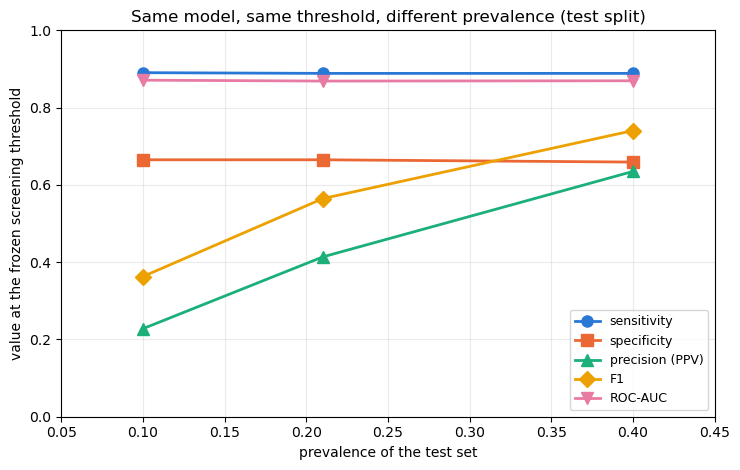

In [53]:
rng = np.random.default_rng(SEED)
repeats = pd.DataFrame([{"target prevalence": target, **shift_metrics(prevalence_subset(target, rng))}
                        for _ in range(200) for target in (0.10, 0.40)])
display(repeats.groupby("target prevalence")[["sensitivity", "specificity", "precision (PPV)", "F1", "ROC-AUC"]]
        .agg(["mean", "std"]).round(4))

METRIC_STYLE = {"sensitivity": ("#2a78d6", "o"), "specificity": ("#eb6834", "s"), "precision (PPV)": ("#1baf7a", "^"),
                "F1": ("#eda100", "D"), "ROC-AUC": ("#e87ba4", "v")}
fig, ax = plt.subplots(figsize=(7.5, 4.8))
xs = shift_table["prevalence"].values
for metric, (color, marker) in METRIC_STYLE.items():
    ax.plot(xs, shift_table[metric].values, color=color, marker=marker, ms=8, lw=2, label=metric)
ax.set(xlabel="prevalence of the test set", ylabel="value at the frozen screening threshold",
       title="Same model, same threshold, different prevalence (test split)", xlim=(0.05, 0.45), ylim=(0, 1))
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### Bonus 1: interpretation

The same model and frozen screening threshold (0.282) were applied to test sets with 10%, 21% and 40% prevalence.

I found that sensitivity, specificity, and ROC-AUC stayed almost unchanged when I changed the prevalence, because these metrics mainly depend on how the model separates positive and negative cases. In contrast, precision changed substantially, increasing from 0.228 at 10% prevalence to 0.635 at 40%, with F1 changing in the same direction. This shows that the same model can produce very different numbers of false alarms depending on how common the disease is in the population. Therefore, before using the model in a new clinical setting, its threshold, expected precision, and calibration should be evaluated using local data.

### Bonus 2: shortcut stress test with a control

I used a masking experiment to test whether the model was relying on information near the image borders. I compared a border mask, which removes the outer 8% containing many markers and text, with an area-matched control mask that removes part of the lung fields. I applied both masks to the test images without retraining the model and measured how much the predicted probabilities and ROC-AUC changed. The control is important because masking itself can affect the model; therefore, only a larger effect from the border mask would provide evidence that the model is specifically using border information.

In [54]:
from scipy.stats import wilcoxon

border_mask = np.zeros((IMG_SIZE, IMG_SIZE), bool)
bw = int(round(0.08 * IMG_SIZE))
border_mask[:bw, :] = True; border_mask[-bw:, :] = True
border_mask[:, :bw] = True; border_mask[:, -bw:] = True

density = np.zeros((IMG_SIZE, IMG_SIZE))
train_boxes = train[train["patientId"].isin(tr_img["patientId"])].dropna(subset=["x"])
for _, bx in train_boxes.iterrows():
    x0, y0 = int(bx["x"] * SCALE), int(bx["y"] * SCALE)
    x1, y1 = int(np.ceil((bx["x"] + bx["width"]) * SCALE)), int(np.ceil((bx["y"] + bx["height"]) * SCALE))
    density[y0:y1, x0:x1] += 1

half_area = border_mask.sum() / 2
RECT_W = int(round(np.sqrt(half_area / 1.5)))
RECT_H = int(round(half_area / RECT_W))
integral = np.pad(density.cumsum(0).cumsum(1), ((1, 0), (1, 0)))

def densest_window(x_lo, x_hi):
    best, best_pos = -1.0, None
    for y in range(bw, IMG_SIZE - bw - RECT_H + 1):
        for x in range(x_lo, x_hi - RECT_W + 1):
            s = integral[y + RECT_H, x + RECT_W] - integral[y, x + RECT_W] - integral[y + RECT_H, x] + integral[y, x]
            if s > best:
                best, best_pos = s, (y, x)
    return best_pos

control_mask = np.zeros((IMG_SIZE, IMG_SIZE), bool)
control_rects = [densest_window(bw, IMG_SIZE // 2), densest_window(IMG_SIZE // 2, IMG_SIZE - bw)]
for y, x in control_rects:
    control_mask[y:y + RECT_H, x:x + RECT_W] = True
assert not (control_mask & border_mask).any()
print(f"border mask: outer {bw} px = {border_mask.mean():.1%} of the image")
print(f"control mask: two {RECT_W}x{RECT_H} px rectangles at (row, col) {control_rects} = {control_mask.mean():.1%} of the image")

FILL_U8 = int(round(TRAIN_MEAN * 255))
example = test_img["patientId"].values[0]
img = X[row_of[example]]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
im = axes[0].imshow(density, cmap="Blues")
for y, x in control_rects:
    axes[0].add_patch(Rectangle((x, y), RECT_W, RECT_H, fill=False, edgecolor="#eb6834", lw=2))
axes[0].add_patch(Rectangle((bw, bw), IMG_SIZE - 2 * bw, IMG_SIZE - 2 * bw, fill=False, edgecolor="#8a8984", lw=1.5, ls="--"))
axes[0].set_title("training box density, control rectangles (orange)\nand inner edge of the border ring (grey)", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046)
for ax, mask, title in [(axes[1], None, "original"), (axes[2], border_mask, "border mask"), (axes[3], control_mask, "control mask")]:
    shown_img = img.copy()
    if mask is not None:
        shown_img[mask] = FILL_U8
    ax.imshow(shown_img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"example test image: {title}", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

border mask: outer 18 px = 29.6% of the image
control mask: two 70x106 px rectangles at (row, col) [(60, 35), (63, 121)] = 29.6% of the image


[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


n  mean Δp  median Δp   SD Δp  mean |Δp|  \
mask            group                                                  
border          all      4996  -0.0353    -0.0096  0.1021     0.0696   
                label 1  1050  -0.0588    -0.0427  0.1127     0.0930   
                label 0  3946  -0.0290    -0.0049  0.0982     0.0633   
                AP       2254  -0.0759    -0.0531  0.1152     0.1000   
                PA       2742  -0.0018    -0.0006  0.0750     0.0445   
control (lungs) all      4996   0.0627     0.1380  0.2645     0.2371   
                label 1  1050  -0.2048    -0.2374  0.2349     0.2702   
                label 0  3946   0.1339     0.1879  0.2231     0.2283   
                AP       2254  -0.0822    -0.1120  0.2700     0.2397   
                PA       2742   0.1819     0.2176  0.1899     0.2350   

                         % with |Δp| > 0.1  
mask            group                       
border          all                25.1601  
                label 1            35.7143  
                label 0            22.3517  
                AP                 38.1544  
                PA                 14.4785  
control (lungs) all                83.3066  
                label 1            84.0000  
                label 0            83.1221  
                AP                 79.7693  
                PA                 86.2144

ROC-AUC: original 0.8687 | border-masked 0.8649 | control-masked 0.7097
paired Wilcoxon signed-rank test, |Δp| border vs |Δp| control: statistic 1134225, p = 0.00e+00; median of |Δp| border - |Δp| control = -0.1802


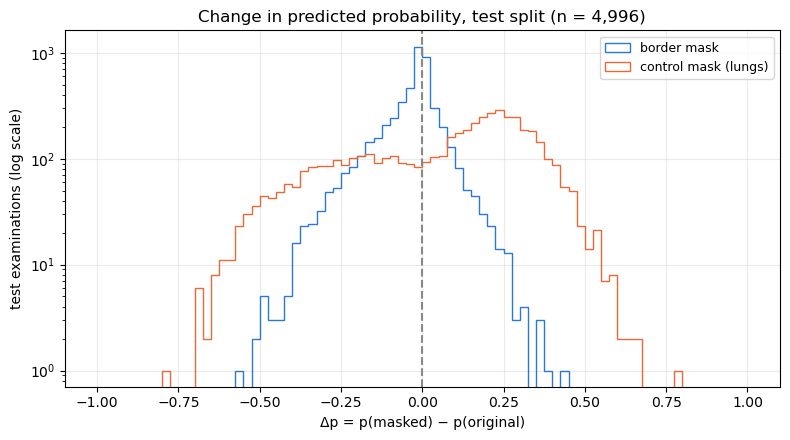

In [55]:
class MaskedDataset(Dataset):
    def __init__(self, base, mask):
        self.base = base
        self.mask = torch.from_numpy(mask)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        x = x.clone()
        x[:, self.mask] = 0.0
        return x, y

_, p_orig = predict(headline_model, test_loader)
_, p_border = predict(headline_model, DataLoader(MaskedDataset(test_ds, border_mask), batch_size=512))
_, p_control = predict(headline_model, DataLoader(MaskedDataset(test_ds, control_mask), batch_size=512))
dp_border = p_border - p_orig
dp_control = p_control - p_orig

def dp_summary(dp):
    return {"n": len(dp), "mean Δp": dp.mean(), "median Δp": np.median(dp), "SD Δp": dp.std(),
            "mean |Δp|": np.abs(dp).mean(), "% with |Δp| > 0.1": 100 * (np.abs(dp) > 0.1).mean()}

groups = [("all", np.ones(len(y_test), bool)), ("label 1", y_test == 1), ("label 0", y_test == 0),
          ("AP", test_view == "AP"), ("PA", test_view == "PA")]
rows = []
for mask_name, dp in [("border", dp_border), ("control (lungs)", dp_control)]:
    for g, sel in groups:
        rows.append({"mask": mask_name, "group": g, **dp_summary(dp[sel])})
dp_table = pd.DataFrame(rows).set_index(["mask", "group"])
display(dp_table.round(4))

print(f"ROC-AUC: original {roc_auc_score(y_test, p_orig):.4f} | border-masked {roc_auc_score(y_test, p_border):.4f} | "
      f"control-masked {roc_auc_score(y_test, p_control):.4f}")
stat, p_value = wilcoxon(np.abs(dp_border), np.abs(dp_control))
print(f"paired Wilcoxon signed-rank test, |Δp| border vs |Δp| control: statistic {stat:.0f}, p = {p_value:.2e}; "
      f"median of |Δp| border - |Δp| control = {np.median(np.abs(dp_border) - np.abs(dp_control)):+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(-1, 1, 81)
ax.hist(dp_border, bins=bins, histtype="step", lw=2, color="#2a78d6", label="border mask")
ax.hist(dp_control, bins=bins, histtype="step", lw=2, color="#eb6834", label="control mask (lungs)")
ax.axvline(0, color="#8a8984", ls="--", lw=1.5)
ax.set_yscale("log")
ax.set(xlabel="Δp = p(masked) − p(original)", ylabel="test examinations (log scale)",
       title="Change in predicted probability, test split (n = 4,996)")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

In [56]:
top3 = np.argsort(-np.abs(dp_border))[:3]
fig, axes = plt.subplots(3, 3, figsize=(11.5, 12))
for r, i in enumerate(top3):
    img = X[row_of[test_img["patientId"].values[i]]]
    masked_img = img.copy()
    masked_img[border_mask] = FILL_U8
    cam_before, _ = grad_cam(headline_model, test_ds[i][0].unsqueeze(0))
    cam_after, _ = grad_cam(headline_model, MaskedDataset(test_ds, border_mask)[i][0].unsqueeze(0))
    panels = [(img, None, f"label {y_test[i]} | {test_view[i]} | original"),
              (img, cam_before[0], f"Grad-CAM before: p = {p_orig[i]:.2f}"),
              (masked_img, cam_after[0], f"after border mask: p = {p_border[i]:.2f} (Δp = {dp_border[i]:+.2f})")]
    for ax, (base, cam, title) in zip(axes[r], panels):
        ax.imshow(base, cmap="gray", vmin=0, vmax=255)
        if cam is not None:
            ax.imshow(cam, cmap="inferno", alpha=0.45, vmin=0, vmax=1)
        ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

[X-ray figure removed from the GitHub copy: medical images are not uploaded (assignment section 5). Re-run this cell locally with the dataset to regenerate it.]


### Bonus 2: interpretation

I found that masking the image border had a much smaller effect than masking the same area within the lungs. Border masking only reduced ROC-AUC from 0.869 to 0.865, while the control lung mask reduced it to 0.710, suggesting that most of the model’s useful information comes from the lung regions. However, the border still had some influence, especially for AP images, where masking it generally lowered the predicted probabilities. This supports my earlier finding that the model may use some acquisition-related information from the image edges, but it is not the model’s main source of discrimination. These results should still be interpreted cautiously because masking creates artificial images that the model did not see during training.